#Classificador de Questões-Problema

Este colab implementa um classificador automático que decide se uma dada questão do POSCOMP é **questão-problema** ou **questão não-problema** (questão direta). O código tem como base o classificador de áreas do conhecimento em questões do POSCOMP, acessível [neste link](https://colab.research.google.com/drive/14tks2YRWvHw1Qo-qrFUr3oc_j_qUFo6A?usp=sharing#scrollTo=K53Sewpetw_r).

## Instalação de dependências



In [ ]:
!pip install openai
!pip install pandas
!pip install tqdm

In [ ]:
import os
from openai import OpenAI
import pandas as pd
import json
from tqdm import tqdm
from datetime import datetime
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, f1_score, accuracy_score
from statsmodels.stats.inter_rater import fleiss_kappa as sm_fleiss_kappa
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [ ]:
tqdm.pandas()

O classificador foi originalmente construído para realizar chamadas ao modelo GPT 5.4. Para que as chamadas sejam bem-sucedidas, é necessário que você insira sua API KEY da OpenAI abaixo.

In [ ]:
API_KEY = "sua chave"

openai = OpenAI(
    api_key = API_KEY
)

## Leitura do *dataset*

Abaixo criamos uma amostra aleatória do dataset. A amostra piloto foi feita com tamanho 30, enquanto a amostra de validação foi feita com 10% do dataset (134 questões).

**Sobre a amostra piloto**

A amostra piloto foi utilizada durante a criação e adaptação do *prompt* do classificador, para garantir que as respostas providas atendem aos critérios e características de uma questão-problema. O prompt foi iterativamente enriquecido até que as respostas do modelo fossem condizentes com o entendimento humano de questão-problema de múltipla escolha da área de computação.

Além disso, a amostra piloto também foi produzida para familiarizar os avaliadores com o tipo e formato de questão encontrada no dataset do POSCOMP, assegurando que todos os avaliadores possuam o mesmo entendimento do que categoriza uma questão-problema.

Devido à natureza iterativa dessa etapa, apenas o prompt final foi registrado de forma persistente.

**Sobre a amostra de validação**

A amostra de validação foi composta de 10% do dataset, o que foi considerado suficientemente representativo para validar se o modelo classifica bem ou não. Essa etapa é tratada em mais detalhes na seção "validação" do colab, após a experimentação. A amostra de validação necessariamente contém apenas questões distintas das presentes na amostra piloto.

**ARQUIVOS NECESSÁRIOS PARA RODAR A SEÇÃO**

O arquivo ```dataset_completo.json``` corresponde ao dataset completo do POSCOMP.

O arquivo ```dataset_piloto.json``` corresponde ao dataset piloto do experimento.

O arquivo ```dataset_amostral.json``` corresponde à amostra de validação.

Descomente a célula que gera a amostra caso queira rodar o código com uma nova amostra, originária do dataset original. Caso contrário, carregue o seu arquivo de preferência como ```dataset.json```. Se estiver reproduzindo o experimento, use os datasets amostrais disponibilizados no GitHub do projeto.

A célula abaixo gera uma amostra de 30 questões, correspondente à amostra piloto.

In [ ]:
"""
#Gerando a amostra piloto do dataset

with open('dataset_completo.json', 'r', encoding='utf-8') as f:
    dataset_completo = json.load(f)

df_completo = pd.DataFrame(dataset_completo)
df_amostra = df_completo.sample(n=30)

output_file_name = 'dataset_piloto.json'
with open(output_file_name, 'w', encoding='utf-8') as f:
    json.dump(df_amostra.to_dict(orient='records'), f, ensure_ascii=False, indent=2)
"""

"\n#Gerando a amostra piloto do dataset\n\nwith open('dataset_completo.json', 'r', encoding='utf-8') as f:\n    dataset_completo = json.load(f)\n\ndf_completo = pd.DataFrame(dataset_completo)\ndf_amostra = df_completo.sample(n=30)\n\noutput_file_name = 'dataset_piloto.json'\nwith open(output_file_name, 'w', encoding='utf-8') as f:\n    json.dump(df_amostra.to_dict(orient='records'), f, ensure_ascii=False, indent=2)\n"

A célula abaixo gera uma amostra de 134 questões, certificando-se de que nenhuma das questões está presente na amostra piloto. Isso corresponde à amostra de validação.

In [ ]:
"""
with open('dataset_completo.json', 'r', encoding='utf-8') as f:
    dataset_completo = json.load(f)

df_completo = pd.DataFrame(dataset_completo)

try:
    with open('dataset.json', 'r', encoding='utf-8') as f:
        dataset_piloto = json.load(f)
    df_piloto = pd.DataFrame(dataset_piloto)
    ids_piloto = df_piloto['id'].tolist()
except FileNotFoundError:
    print("dataset.json not found, proceeding with full dataset_completo.")
    ids_piloto = []

df_disponivel = df_completo[~df_completo['id'].isin(ids_piloto)]

df_amostra_validacao = df_disponivel.sample(n=134, random_state=42)

output_file_name_amostral = 'dataset_amostral.json'
with open(output_file_name_amostral, 'w', encoding='utf-8') as f:
    json.dump(df_amostra_validacao.to_dict(orient='records'), f, ensure_ascii=False, indent=2)
"""

'\nwith open(\'dataset_completo.json\', \'r\', encoding=\'utf-8\') as f:\n    dataset_completo = json.load(f)\n\ndf_completo = pd.DataFrame(dataset_completo)\n\ntry:\n    with open(\'dataset.json\', \'r\', encoding=\'utf-8\') as f:\n        dataset_piloto = json.load(f)\n    df_piloto = pd.DataFrame(dataset_piloto)\n    ids_piloto = df_piloto[\'id\'].tolist()\nexcept FileNotFoundError:\n    print("dataset.json not found, proceeding with full dataset_completo.")\n    ids_piloto = []\n\ndf_disponivel = df_completo[~df_completo[\'id\'].isin(ids_piloto)]\n\ndf_amostra_validacao = df_disponivel.sample(n=134, random_state=42)\n\noutput_file_name_amostral = \'dataset_amostral.json\'\nwith open(output_file_name_amostral, \'w\', encoding=\'utf-8\') as f:\n    json.dump(df_amostra_validacao.to_dict(orient=\'records\'), f, ensure_ascii=False, indent=2)\n'

Abaixo, salvamos uma versão simplificada da amostra de validação, contendo apenas o id e o enunciado da questão, para enviar aos anotadores humanos.

In [ ]:
#df_amostra_validacao[['id', 'enunciado']].to_csv('dataset_amostral_avaliacao_humana.csv', index=False)

No restante desta seção, apenas carregamos e preparamos o dataset para o processamento futuro, salvando as colunas de interesse.

In [ ]:
poscomp_ds = pd.read_json('dataset.json') #lembre-se de renomear seu dataset aqui ou na aba de arquivos!

In [ ]:
colunas_relevantes = [
    'id',
    'enunciado'
]

poscomp_ds.head(5)

,id,edicao,numero,enunciado,alternativas,area_conhecimento,area,subarea,gabarito,atributo_rag
0,2002-01,2002,1,Pode-se afirmar que o gráfico da função $y = 2...,[a) transladado uma unidade para a direita e d...,Matemática,Geometria Analítica,Reta no plano e no espaço,A,matematica - geometria analitica - reta no pla...
1,2002-02,2002,2,A derivada da função $f(x) = x^x$ é igual a,"[a) $xx^{x-1}$, b) $x^x$, c) $x^x \ln(x)$, d) ...",Matemática,Cálculo Diferencial e Integral,Funções Reais de uma Variável: Continuidade e ...,D,matematica - calculo diferencial e integral - ...
2,2002-03,2002,3,Seja $n$ um número inteiro positivo. Considere...,"[a) 5, b) 4, c) 6, d) 3, e) 2]",Matemática,Matemática Discreta,"Iteração, Indução e Recursão",B,"matematica - matematica discreta - iteracao, i..."
3,2002-04,2002,4,"Para cada $n \in \mathbb{N}$ seja $D_n = (0, 1...","[a) $D_3$, b) $D_{20}$, c) $(1/20, 1/3)$, d) $...",Matemática,Matemática Discreta,Conjuntos e Álgebra de Conjuntos como uma Teor...,D,matematica - matematica discreta - conjuntos e...
4,2002-05,2002,5,Todos os convidados presentes num jantar tomam...,"[a) 19, b) 27, c) 23, d) 15, e) 10]",Matemática,Análise Combinatória,Princípio de Inclusão e Exclusão,A,matematica - analise combinatoria - principio ...


In [ ]:
poscomp_ds['alternativas_str_parcial'] = poscomp_ds['alternativas'].apply(lambda x: x[0])
poscomp_ds.head(5)

,id,edicao,numero,enunciado,alternativas,area_conhecimento,area,subarea,gabarito,atributo_rag,alternativas_str_parcial
0,2002-01,2002,1,Pode-se afirmar que o gráfico da função $y = 2...,[a) transladado uma unidade para a direita e d...,Matemática,Geometria Analítica,Reta no plano e no espaço,A,matematica - geometria analitica - reta no pla...,a) transladado uma unidade para a direita e du...
1,2002-02,2002,2,A derivada da função $f(x) = x^x$ é igual a,"[a) $xx^{x-1}$, b) $x^x$, c) $x^x \ln(x)$, d) ...",Matemática,Cálculo Diferencial e Integral,Funções Reais de uma Variável: Continuidade e ...,D,matematica - calculo diferencial e integral - ...,a) $xx^{x-1}$
2,2002-03,2002,3,Seja $n$ um número inteiro positivo. Considere...,"[a) 5, b) 4, c) 6, d) 3, e) 2]",Matemática,Matemática Discreta,"Iteração, Indução e Recursão",B,"matematica - matematica discreta - iteracao, i...",a) 5
3,2002-04,2002,4,"Para cada $n \in \mathbb{N}$ seja $D_n = (0, 1...","[a) $D_3$, b) $D_{20}$, c) $(1/20, 1/3)$, d) $...",Matemática,Matemática Discreta,Conjuntos e Álgebra de Conjuntos como uma Teor...,D,matematica - matematica discreta - conjuntos e...,a) $D_3$
4,2002-05,2002,5,Todos os convidados presentes num jantar tomam...,"[a) 19, b) 27, c) 23, d) 15, e) 10]",Matemática,Análise Combinatória,Princípio de Inclusão e Exclusão,A,matematica - analise combinatoria - principio ...,a) 19


In [ ]:
poscomp_ds['texto_parcial'] = poscomp_ds['enunciado'] + '\n\n' + poscomp_ds['alternativas_str_parcial']

colunas_relevantes.extend(['texto_parcial'])
poscomp_ds = poscomp_ds[colunas_relevantes]

In [ ]:
poscomp_ds.head()

,id,enunciado,texto_parcial
0,2002-01,Pode-se afirmar que o gráfico da função $y = 2...,Pode-se afirmar que o gráfico da função $y = 2...
1,2002-02,A derivada da função $f(x) = x^x$ é igual a,A derivada da função $f(x) = x^x$ é igual a\n\...
2,2002-03,Seja $n$ um número inteiro positivo. Considere...,Seja $n$ um número inteiro positivo. Considere...
3,2002-04,"Para cada $n \in \mathbb{N}$ seja $D_n = (0, 1...","Para cada $n \in \mathbb{N}$ seja $D_n = (0, 1..."
4,2002-05,Todos os convidados presentes num jantar tomam...,Todos os convidados presentes num jantar tomam...


## Geração de *prompts*

A função `gerar_prompt` trata o enunciado da questão para adequá-lo ao formato de mensagem que será enviado à LLM.

In [ ]:
def gerar_prompt(questao):
  PROMPT = f"""
QUESTÃO:
{questao['enunciado']}
"""

  return PROMPT

Abaixo, encontramos o núcleo do classificador, que essencialmente aplica engenharia de prompt para obter as classificações segundo definições operacionais de questão-problema e questão direta, adaptadas para o contexto do POSCOMP.

Para aplicar este classificador a outros contextos, disciplinas, formatos de questão e áreas do conhecimento, você deve apenas modificar os detalhes das definições.

In [ ]:
SYSTEM_PROMPT = """
Você é um classificador de questões.
Sua tarefa é classificar uma questão em duas categorias mutuamente exclusivas:
QUESTÃO-PROBLEMA ou QUESTÃO-DIRETA.
Você receberá uma questão simplificada da área de Computação de múltipla escolha,
contendo seu enunciado.
Avalie a questão com base nas orientações abaixo, concentrando-se no contexto
semântico da questão. Nunca tente resolver ou adicionar outro texto além
do que se pede no formato de resposta.

DEFINIÇÃO DE QUESTÃO-PROBLEMA DE MÚLTIPLA ESCOLHA:
Uma questão-problema de múltipla escolha apresenta uma situação concreta e operável
para o respondente, exigindo raciocínio situacional. Geralmente, apresenta cenários
fictícios onde o conteúdo da disciplina é usado, mas não de forma mecânica, e sim
após análise ou avaliação de um problema inédito. Na área da Computação, situações
concretas englobam exemplos de uso de um conteúdo, algoritmo, método ou ferramenta
no cotidiano, proposição de novos algoritmos ou mudança de algoritmos conhecidos,
análise de código, pseudocódigo, diagramas, linguagens, sistemas computacionais
parametrizados e específicos de uma situação hipotética (mesmo que simples) que exigem
raciocinar sobre o comportamento ou resultado, inclusive sob hipóteses
de reconfiguração, otimização, análises e melhorias... entre outros.

DEFINIÇÃO DE QUESTÃO DIRETA DE MÚLTIPLA ESCOLHA:
Uma questão direta solicita uma resolução mecânica, geralmente apoiada pela
evocação direta de um conteúdo ou conceito, ou aplicação mecânica de um conteúdo.
Geralmente, o enunciado não apresenta contexto situacional ou cenário fictício.
Questões do tipo "A definição de X é..." ou "Calcule...", que simplesmente solicitam
procedimentos matemáticos, lembrança, compreensão ou definição de um conteúdo são
questões diretas.

ORIENTAÇÕES EM CASO DE DÚVIDA:
- Algumas questões apresentam contexto situacional no enunciado, mas o comando e as
alternativas não se comunicam com o exemplo ou situação apresentada. Quando o comando
e as alternativas são diretas e não se comunicam com o contexto, a questão é DIRETA.
- Algumas questões solicitam procedimentos mecânicos após apresentar uma situação simples,
como "considere o sistema X que usa os recursos A, B e C... calcule Y". Nesse caso, é
preciso considerar o contexto semântico do comando da questão e das alternativas. Se
o comando e as alternativas apresentam algum nível crítico de raciocínio, mobilização de
conhecimento, comparação de soluções, análise ou avaliação de diferentes situações, então
a questão é PROBLEMA. Caso solicite apenas cálculo, definição de um conceito, encontrar a
alternativa correta ou incorreta sobre o conceito, aplicação direta de conteúdo, então é
questão DIRETA.
- Em caso de empate, pense: "se eu tirar o contexto dessa questão e substituir por um
comando simples, ainda consigo resolvê-la?".
Se sim, é questão DIRETA. Se não, é questão PROBLEMA.
- Se a questão apresenta código, pseudocódigo, diagrama, consulta a banco de dados ou
apresentação de sistema/arquitetura computacional hipotéticos e/ou parametrizados cuja
resolução depende fortemente da composição apresentada, em geral, ela é PROBLEMA.

ORIENTAÇÃO GERAL:
Em geral, se a questão é conceitual ou pede apenas um procedimento mecânico direto, ela é DIRETA.
Se apresenta um contexto, exemplo, cenário hipotético, código ou pseudocódigo, mesmo que simples, ela
é PROBLEMA.

FORMATO DE RESPOSTA:
True para questão-problema, False caso contrário.
"""

##Funções de comportamento do modelo

Nesta seção, definimos que modelo iremos usar e seus hiperparâmetros de comportamento.

A fim de manter a replicação fiel ao classificador original, de áreas do conhecimento, utilizaram-se os mesmos hiperparâmetros na função `get_completion`.

A função `recupera_resposta` usa do `get_completion` para recuperar a decisão do modelo, ou seja, se a questão é problema (true) ou direta (false). Por fim, a função `iteracao_prompt` realiza chamadas à `recupera_resposta` para salvar as respostas de cada questão no dataset.

In [ ]:
def get_completion(prompt, model, system_prompt):
    chat_completion = openai.chat.completions.create(
        model = model,
        messages = [
            { "role": "system", "content": system_prompt },
            { "role": "user", "content": prompt }
        ],
        temperature = 0.7,
    )

    return chat_completion

In [ ]:
def recupera_resposta(questao):
  obj = get_completion(questao['prompt'], "gpt-5.4", SYSTEM_PROMPT)
  return (obj.choices[0].message.content)

In [ ]:
def iteracao_prompt(dataset, n_iteracao):
  model_responses = dataset.progress_apply(lambda x: recupera_resposta(x), axis=1)

  col_name = f'it{n_iteracao}_ehQuestaoProblema'

  dataset[col_name] = None

  for idx, response_str in model_responses.items():
    clean_response = str(response_str).strip().lower()
    if clean_response == 'true':
      dataset.loc[idx, col_name] = True
    elif clean_response == 'false':
      dataset.loc[idx, col_name] = False

  return dataset

##Medidas de avaliação

A medida central de avaliação do classificador é o índice de concordância Kappa, que mede a concordância entre avaliadores (humanos ou simulados), descontando acertos ocorridos ao acaso. Abaixo, implementamos as funções necessárias para produzir e interpretar os valores de concordância.

Em `c_kappa`, calcula-se o índice Kappa de Cohen, utilizado quando há apenas dois avaliadores. Esta função é usada quando se quer comparar pontualmente um avaliador com o outro, ou a média de avaliadores com a média das iterações do modelo, por exemplo.

A função recebe o dataframe e os identificadores das colunas a comparar.

In [ ]:
def c_kappa(df, col1_name, col2_name):
    cleaned_df = df.dropna(subset=[col1_name, col2_name]).copy()

    rater1 = cleaned_df[col1_name].astype(bool)
    rater2 = cleaned_df[col2_name].astype(bool)

    kappa = cohen_kappa_score(rater1, rater2)
    return kappa

Em `f_kappa`, calcula-se o índice Fleiss Kappa, utilizado quando há mais de dois avaliadores. Esta função é escolhida quando se quer comparar diretamente todos os avaliadores (3, neste experimento) ou todas as iterações.

A função recebe o dataframe e uma lista com os identificadores das colunas a comparar.

In [ ]:
def f_kappa(df, column_names):
    ratings_df = df[column_names].astype(int)
    ratings_df = ratings_df.dropna()

    data_for_kappa = ratings_df.to_numpy()
    num_subjects = ratings_df.shape[0]
    num_categories = 2

    transformed_data = []
    for _, row in ratings_df.iterrows():
        counts = [0] * num_categories
        for rating in row:
            if rating in [0, 1]:
                counts[int(rating)] += 1
        transformed_data.append(counts)

    fleiss_k = sm_fleiss_kappa(transformed_data)
    return fleiss_k

A função `nivel_kappa` interpreta o valor de kappa. Na literatura, a interpretação mais comum é a de faixas de concordância, traduzida para código abaixo.

In [ ]:
def nivel_kappa(v):
  if v < 0:
    return "Ausência de concordância"
  elif v >= 0 and v <= 0.20:
    return "Concordância leve"
  elif v > 0.20 and v <= 0.40:
    return "Concordância razoável"
  elif v > 0.40 and v <= 0.60:
    return "Concordância moderada"
  elif v > 0.60 and v <= 0.80:
    return "Concordância substancial"
  elif v > 0.80 and v <= 1:
    return "Concordância quase perfeita"
  else:
    return "O valor de Kappa não pode ser maior do que 1"

Além do kappa, também calculou-se a concordância simples de classificação, sem os descontos produzidos pelo acaso. As funções abaixo recebem o dataframe, as colunas a comparar, e retornam a quantidade e porcentagem de concordâncias.

In [ ]:
def concordancia_simples_2_colunas(df, col1_name, col2_name):
    cleaned_df = df.dropna(subset=[col1_name, col2_name]).copy()

    match_count = (cleaned_df[col1_name] == cleaned_df[col2_name]).sum()
    total_rows = len(cleaned_df)
    percentage_agreement = (match_count / total_rows) * 100 if total_rows > 0 else 0

    return match_count, percentage_agreement

In [ ]:
def concordancia_simples_3_colunas(df, col1_name, col2_name, col3_name):

    cleaned_df = df.dropna(subset=[col1_name, col2_name, col3_name]).copy()

    match_count = ((cleaned_df[col1_name] == cleaned_df[col2_name]) &
                   (cleaned_df[col2_name] == cleaned_df[col3_name])).sum()
    total_rows = len(cleaned_df)
    percentage_agreement = (match_count / total_rows) * 100 if total_rows > 0 else 0

    return match_count, percentage_agreement

## Experimento piloto

### Organização do dataset e execução

O experimento piloto opera sobre 30 questões aleatórias do POSCOMP. Abaixo, organizamos e preparamos essas questões, geramos o prompt para elas e, então, ajustamos o prompt do sistema iterativamente, realizando repetidamente as classificações automáticas.

In [ ]:
poscomp_ds['prompt'] = poscomp_ds.apply(gerar_prompt, axis = 1)

In [ ]:
poscomp_ds.head(5)

,id,enunciado,texto_parcial,prompt
0,2002-57,"Sistemas de processamento de transações, tais ...","Sistemas de processamento de transações, tais ...",\nQUESTÃO:\nSistemas de processamento de trans...
1,2003-01,Seja $f : \mathbb{R} \to \mathbb{R}$ definida ...,Seja $f : \mathbb{R} \to \mathbb{R}$ definida ...,\nQUESTÃO:\nSeja $f : \mathbb{R} \to \mathbb{R...
2,2003-17,"Assinale o argumento válido, onde $S_1$ e $S_2...","Assinale o argumento válido, onde $S_1$ e $S_2...","\nQUESTÃO:\nAssinale o argumento válido, onde ..."
3,2005-07,Considere as afirmações a seguir:\n\n(I) Se $f...,Considere as afirmações a seguir:\n\n(I) Se $f...,\nQUESTÃO:\nConsidere as afirmações a seguir:\...
4,2005-36,"Quatro tarefas, A, B, C e D, estão prontas par...","Quatro tarefas, A, B, C e D, estão prontas par...","\nQUESTÃO:\nQuatro tarefas, A, B, C e D, estão..."


In [ ]:
colunas_interesse = [
  'id',
  'enunciado',
  'prompt'
]

In [ ]:
poscomp_ds = poscomp_ds[colunas_interesse]
poscomp_ds.head(5)

,id,enunciado,prompt
0,2002-57,"Sistemas de processamento de transações, tais ...",\nQUESTÃO:\nSistemas de processamento de trans...
1,2003-01,Seja $f : \mathbb{R} \to \mathbb{R}$ definida ...,\nQUESTÃO:\nSeja $f : \mathbb{R} \to \mathbb{R...
2,2003-17,"Assinale o argumento válido, onde $S_1$ e $S_2...","\nQUESTÃO:\nAssinale o argumento válido, onde ..."
3,2005-07,Considere as afirmações a seguir:\n\n(I) Se $f...,\nQUESTÃO:\nConsidere as afirmações a seguir:\...
4,2005-36,"Quatro tarefas, A, B, C e D, estão prontas par...","\nQUESTÃO:\nQuatro tarefas, A, B, C e D, estão..."


In [ ]:
n_questao = 1
questao = poscomp_ds.iloc[n_questao]

In [ ]:
print(SYSTEM_PROMPT)
print(questao["prompt"])


Você é um classificador de questões.
Sua tarefa é classificar uma questão em duas categorias mutuamente exclusivas:
QUESTÃO-PROBLEMA ou QUESTÃO-DIRETA.
Você receberá uma questão simplificada da área de Computação de múltipla escolha,
contendo seu enunciado.
Avalie a questão com base nas orientações abaixo, concentrando-se no contexto
semântico da questão. Nunca tente resolver ou adicionar outro texto além
do que se pede no formato de resposta.

DEFINIÇÃO DE QUESTÃO-PROBLEMA DE MÚLTIPLA ESCOLHA:
Uma questão-problema de múltipla escolha apresenta uma situação concreta e operável
para o respondente, exigindo raciocínio situacional. Geralmente, apresenta cenários
fictícios onde o conteúdo da disciplina é usado, mas não de forma mecânica, e sim
após análise ou avaliação de um problema inédito. Na área da Computação, situações
concretas englobam exemplos de uso de um conteúdo, algoritmo, método ou ferramenta
no cotidiano, proposição de novos algoritmos ou mudança de algoritmos conhecidos,
a

In [ ]:
#print(recupera_resposta(questao))

Nesta etapa, trabalhamos com apenas uma execução concreta, pois o experimento é re-executado a cada ajuste do protocolo de classificação (prompt).

In [ ]:
n_it_piloto = 1
poscomp_ds = iteracao_prompt(poscomp_ds, n_it_piloto)

100%|██████████| 30/30 [00:22<00:00,  1.34it/s]


In [ ]:
poscomp_ds

,id,enunciado,prompt,it1_ehQuestaoProblema
0,2002-57,"Sistemas de processamento de transações, tais ...",\nQUESTÃO:\nSistemas de processamento de trans...,False
1,2003-01,Seja $f : \mathbb{R} \to \mathbb{R}$ definida ...,\nQUESTÃO:\nSeja $f : \mathbb{R} \to \mathbb{R...,False
2,2003-17,"Assinale o argumento válido, onde $S_1$ e $S_2...","\nQUESTÃO:\nAssinale o argumento válido, onde ...",False
3,2005-07,Considere as afirmações a seguir:\n\n(I) Se $f...,\nQUESTÃO:\nConsidere as afirmações a seguir:\...,False
4,2005-36,"Quatro tarefas, A, B, C e D, estão prontas par...","\nQUESTÃO:\nQuatro tarefas, A, B, C e D, estão...",True
5,2005-44,Sejam T1 e T2 duas transações sendo processada...,\nQUESTÃO:\nSejam T1 e T2 duas transações send...,True
6,2006-57,O código abaixo implementa uma função que calc...,\nQUESTÃO:\nO código abaixo implementa uma fun...,True
7,2008-32,Analise as seguintes afirmativas.\n\nI. Uma ar...,\nQUESTÃO:\nAnalise as seguintes afirmativas.\...,False
8,2008-54,Um processador tem cinco estágios de *pipeline...,\nQUESTÃO:\nUm processador tem cinco estágios ...,False
9,2009-26,Considere uma arquitetura de memória com as se...,\nQUESTÃO:\nConsidere uma arquitetura de memór...,False


In [ ]:
poscomp_ds.to_csv(f'dataset_it{n_it_piloto}_piloto.csv', index=False)

###Comparando o piloto com a avaliação humana (3 avaliadores)

Para validar esta etapa do experimento, três anotadores classificaram manualmente as 30 questões piloto. A anotação foi realizada às cegas. Ou seja, nenhum anotador conhece as respostas de outro. O dataset produzido com as três classificações diferentes é carregado abaixo, onde tira-se a média simples das classificações para produzir um gabarito.

É com este gabarito que o resultado da classificação automática é comparado, até que o protocolo produza consistentemente bons resultados.

In [ ]:
avs_piloto_ds = pd.read_csv('dataset_avs_piloto.csv')
md_piloto_ds = pd.read_csv('dataset_modelo_piloto.csv') #renomeie o dataset_it1_piloto para dataset_modelo_piloto

In [ ]:
piloto_df = md_piloto_ds.merge(avs_piloto_ds[['id', 'av1_ehQuestaoProblema','av2_ehQuestaoProblema', 'av3_ehQuestaoProblema' ]], on='id', how='left')

In [ ]:
piloto_df['av1_ehQuestaoProblema_numeric'] = piloto_df['av1_ehQuestaoProblema'].astype(int)
piloto_df['av2_ehQuestaoProblema_numeric'] = piloto_df['av2_ehQuestaoProblema'].astype(int)
piloto_df['av3_ehQuestaoProblema_numeric'] = piloto_df['av3_ehQuestaoProblema'].astype(int)

piloto_df['avs_ehQuestaoProblema'] = (piloto_df[['av1_ehQuestaoProblema_numeric', 'av2_ehQuestaoProblema_numeric', 'av3_ehQuestaoProblema_numeric']].sum(axis=1) >= 2)

piloto_df = piloto_df.drop(columns=['av1_ehQuestaoProblema_numeric', 'av2_ehQuestaoProblema_numeric', 'av3_ehQuestaoProblema_numeric'])

In [ ]:
piloto_df.head(1)

,id,enunciado,prompt,it1_ehQuestaoProblema,av1_ehQuestaoProblema,av2_ehQuestaoProblema,av3_ehQuestaoProblema,avs_ehQuestaoProblema
0,2002-57,"Sistemas de processamento de transações, tais ...",\nQUESTÃO:\nSistemas de processamento de trans...,False,False,False,False,False


In [ ]:
def relatorio_simples_piloto(coluna1,coluna2):

  match_count, percentage_matches = concordancia_simples_2_colunas(piloto_df, coluna1, coluna2)
  k = c_kappa(piloto_df, coluna1, coluna2)
  nivel_k = nivel_kappa(k)

  print(f"\nNúmero de correspondências: {match_count} de {len(piloto_df)}")
  print(f"Porcentagem de correspondências: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância: {nivel_k}")

In [ ]:
def relatorio_media_piloto(coluna1,coluna2,coluna3):

  match_count, percentage_matches = concordancia_simples_3_colunas(piloto_df, coluna1, coluna2,coluna3)
  k = f_kappa(piloto_df, [coluna1, coluna2,coluna3])
  nivel_k = nivel_kappa(k)

  print(f"\nNúmero de correspondências: {match_count} de {len(piloto_df)}")
  print(f"Porcentagem de correspondências: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância: {nivel_k}")

In [ ]:
print("Resultados do piloto entre modelo e avaliador 1")

relatorio_simples_piloto('it1_ehQuestaoProblema', 'av1_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre modelo e avaliador 2")

relatorio_simples_piloto('it1_ehQuestaoProblema', 'av2_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre modelo e avaliador 3")

relatorio_simples_piloto('it1_ehQuestaoProblema', 'av3_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre modelo e a média dos avaliadores")

relatorio_simples_piloto('it1_ehQuestaoProblema', 'avs_ehQuestaoProblema')

Resultados do piloto entre modelo e avaliador 1

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.92
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre modelo e avaliador 2

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.84
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre modelo e avaliador 3

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.85
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre modelo e a média dos avaliadores

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.92
Ní

In [ ]:
print("Resultados do piloto entre avaliador 1 e avaliador 2")

relatorio_simples_piloto('av1_ehQuestaoProblema', 'av2_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre avaliador 1 e avaliador 3")

relatorio_simples_piloto('av1_ehQuestaoProblema', 'av3_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre avaliador 2 e avaliador 3")

relatorio_simples_piloto('av2_ehQuestaoProblema', 'av3_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre avaliadores")

relatorio_media_piloto('av2_ehQuestaoProblema','av2_ehQuestaoProblema', 'av3_ehQuestaoProblema')

Resultados do piloto entre avaliador 1 e avaliador 2

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.92
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre avaliador 1 e avaliador 3

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.93
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre avaliador 2 e avaliador 3

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.85
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre avaliadores

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.90
Nível de

In [ ]:
print("Resultados do piloto entre avaliador 1 e a média dos avaliadores")

relatorio_simples_piloto('av1_ehQuestaoProblema', 'avs_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre avaliador 2 e a média dos avaliadores")

relatorio_simples_piloto('av2_ehQuestaoProblema', 'avs_ehQuestaoProblema')

print("_____________________________________________________________")

print("\nResultados do piloto entre avaliador 3 e a média dos avaliadores")

relatorio_simples_piloto('av3_ehQuestaoProblema', 'avs_ehQuestaoProblema')

Resultados do piloto entre avaliador 1 e a média dos avaliadores

Número de correspondências: 30 de 30
Porcentagem de correspondências: 100.00%
Índice de concordância Kappa: 1.00
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre avaliador 2 e a média dos avaliadores

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.92
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Resultados do piloto entre avaliador 3 e a média dos avaliadores

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.93
Nível de concordância: Concordância quase perfeita


In [ ]:
divergent_questions = piloto_df[
    (piloto_df['it1_ehQuestaoProblema'] != piloto_df['av1_ehQuestaoProblema']) |
    (piloto_df['it1_ehQuestaoProblema'] != piloto_df['av2_ehQuestaoProblema']) |
    (piloto_df['it1_ehQuestaoProblema'] != piloto_df['av3_ehQuestaoProblema']) |
    (piloto_df['av1_ehQuestaoProblema'] != piloto_df['av2_ehQuestaoProblema']) |
    (piloto_df['av1_ehQuestaoProblema'] != piloto_df['av3_ehQuestaoProblema']) |
    (piloto_df['av2_ehQuestaoProblema'] != piloto_df['av3_ehQuestaoProblema'])
]

if not divergent_questions.empty:
    print("Questões com divergência nas classificações:")
    display(divergent_questions[['id', 'enunciado', 'it1_ehQuestaoProblema', 'av1_ehQuestaoProblema', 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema']])
else:
    print("Não houve divergência nas classificações.")

Questões com divergência nas classificações:


,id,enunciado,it1_ehQuestaoProblema,av1_ehQuestaoProblema,av2_ehQuestaoProblema,av3_ehQuestaoProblema
4,2005-36,"Quatro tarefas, A, B, C e D, estão prontas par...",True,True,False,True
8,2008-54,Um processador tem cinco estágios de *pipeline...,False,False,False,True
9,2009-26,Considere uma arquitetura de memória com as se...,False,True,True,True


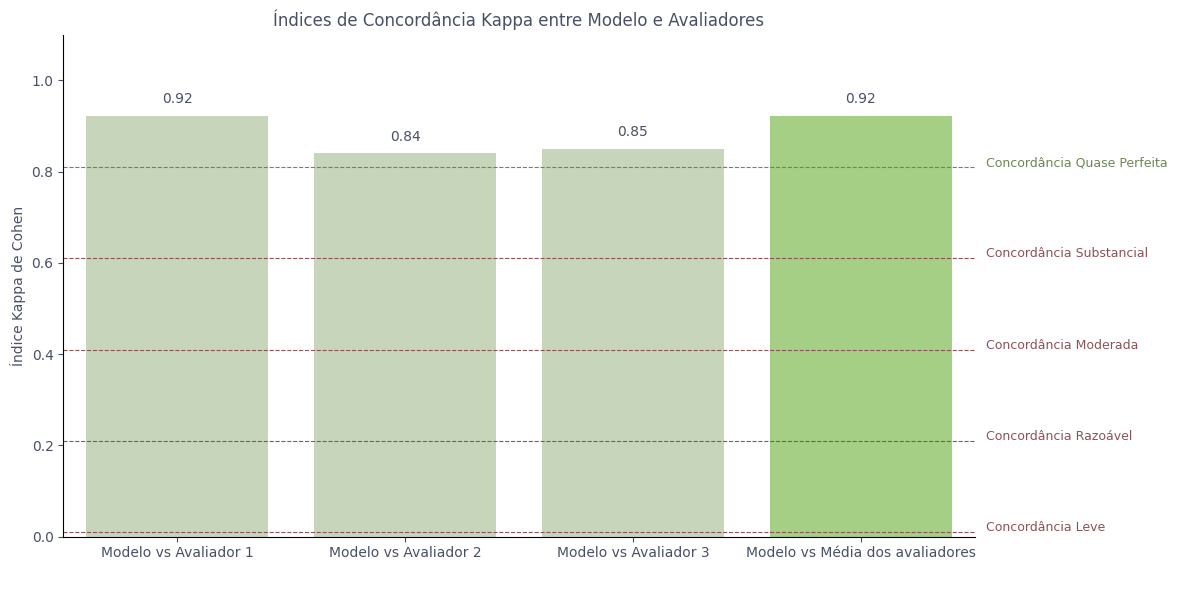

In [ ]:
k_it1_av1 = c_kappa(piloto_df, 'it1_ehQuestaoProblema', 'av1_ehQuestaoProblema')
k_it1_av2 = c_kappa(piloto_df, 'it1_ehQuestaoProblema', 'av2_ehQuestaoProblema')
k_it1_av3 = c_kappa(piloto_df, 'it1_ehQuestaoProblema', 'av3_ehQuestaoProblema')
k_it1_avs = c_kappa(piloto_df, 'it1_ehQuestaoProblema', 'avs_ehQuestaoProblema')

labels = ['Modelo vs Avaliador 1', 'Modelo vs Avaliador 2', 'Modelo vs Avaliador 3', 'Modelo vs Média dos avaliadores']
kappas = [k_it1_av1, k_it1_av2, k_it1_av3, k_it1_avs]

plot_df = pd.DataFrame({
    'Comparação': labels,
    'Kappa': kappas
})

hex_codes = {
    "green": "#C7D9B7",
    "green_2": "#6B8851",
    "green_3": "#A4DB77",
    "red": "#CF8E93",
    "red_2": "#8C5257",
    "red_3": "#BB4C55",
    "gray": "#485065"
}

colors = []
for i, k in enumerate(kappas):
    if labels[i] == 'Modelo vs Média dos avaliadores':
        if k < 0.8:
            colors.append(hex_codes["red_3"])
        else:
            colors.append(hex_codes["green_3"])
    else:
        if k < 0.8:
            colors.append(hex_codes["red"])
        else:
            colors.append(hex_codes["green"])

plt.rcParams['text.color'] = hex_codes["gray"]
plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
plt.rcParams['xtick.color'] = hex_codes["gray"]
plt.rcParams['ytick.color'] = hex_codes["gray"]

plt.figure(figsize=(14, 6))
ax = plt.gca()

sns.barplot(x='Comparação', y='Kappa', data=plot_df, palette=colors, hue='Comparação', legend=False, ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel(' ', color=hex_codes["gray"])
plt.ylabel('Índice Kappa de Cohen', color=hex_codes["gray"])
plt.title('Índices de Concordância Kappa entre Modelo e Avaliadores', color=hex_codes["gray"])
plt.ylim(0, 1.1)

kappa_level_definitions = [
    (0.01, "Concordância Leve"),
    (0.21, "Concordância Razoável"),
    (0.41, "Concordância Moderada"),
    (0.61, "Concordância Substancial"),
    (0.81, "Concordância Quase Perfeita")
]

for threshold, level_text in kappa_level_definitions:
    line_and_text_color = hex_codes["green_2"] if level_text == "Concordância Quase Perfeita" else hex_codes["red_2"]

    plt.axhline(y=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)

    plt.text(ax.get_xlim()[1] + 0.05, threshold + 0.01, level_text,
             va='center', ha='left', color=line_and_text_color, fontsize=9)

for i, value in enumerate(kappas):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', va='bottom', color=hex_codes["gray"])

plt.xticks(ha='center', color=hex_codes["gray"])
plt.yticks(color=hex_codes["gray"])

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Vê-se que a última execução do experimento piloto produziu um kappa entre a classificação automática e o gabarito de 0.92, na faixa "quase perfeita". Assim, os resultados foram considerados satisfatórios para continuar para a etapa de validação.

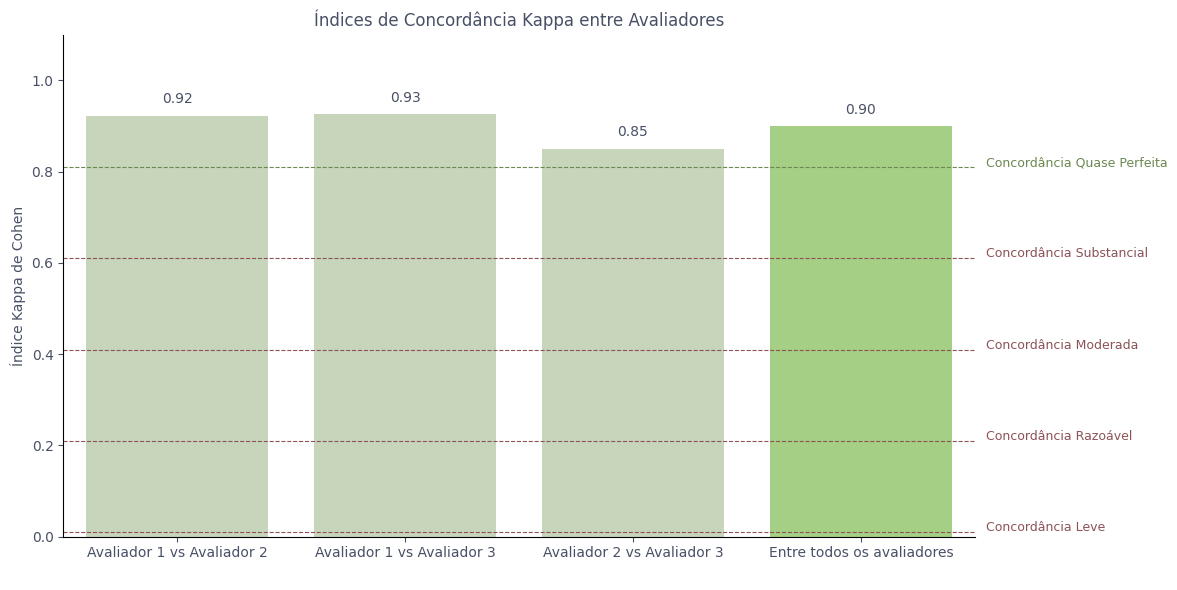

In [ ]:
k_av1_av2 = c_kappa(piloto_df, 'av1_ehQuestaoProblema', 'av2_ehQuestaoProblema')
k_av1_av3 = c_kappa(piloto_df, 'av1_ehQuestaoProblema', 'av3_ehQuestaoProblema')
k_av2_av3 = c_kappa(piloto_df, 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema')
k_avs = f_kappa(piloto_df, ['av1_ehQuestaoProblema', 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema'])

labels = ['Avaliador 1 vs Avaliador 2', 'Avaliador 1 vs Avaliador 3','Avaliador 2 vs Avaliador 3','Entre todos os avaliadores',]
kappas = [k_av1_av2, k_av1_av3, k_av2_av3, k_avs]

plot_df = pd.DataFrame({
    'Comparação': labels,
    'Kappa': kappas
})

hex_codes = {
    "green": "#C7D9B7",
    "green_2": "#6B8851",
    "green_3": "#A4DB77",
    "red": "#CF8E93",
    "red_2": "#8C5257",
    "red_3": "#BB4C55",
    "gray": "#485065"
}

colors = []
for i, k in enumerate(kappas):
    if labels[i] == 'Entre todos os avaliadores':
        if k < 0.8:
            colors.append(hex_codes["red_3"])
        else:
            colors.append(hex_codes["green_3"])
    else:
        if k < 0.8:
            colors.append(hex_codes["red"])
        else:
            colors.append(hex_codes["green"])

plt.rcParams['text.color'] = hex_codes["gray"]
plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
plt.rcParams['xtick.color'] = hex_codes["gray"]
plt.rcParams['ytick.color'] = hex_codes["gray"]

plt.figure(figsize=(14, 6))
ax = plt.gca()

sns.barplot(x='Comparação', y='Kappa', data=plot_df, palette=colors, hue='Comparação', legend=False, ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel(' ', color=hex_codes["gray"])
plt.ylabel('Índice Kappa de Cohen', color=hex_codes["gray"])
plt.title('Índices de Concordância Kappa entre Avaliadores', color=hex_codes["gray"])
plt.ylim(0, 1.1)

kappa_level_definitions = [
    (0.01, "Concordância Leve"),
    (0.21, "Concordância Razoável"),
    (0.41, "Concordância Moderada"),
    (0.61, "Concordância Substancial"),
    (0.81, "Concordância Quase Perfeita")
]

for threshold, level_text in kappa_level_definitions:
    line_and_text_color = hex_codes["green_2"] if level_text == "Concordância Quase Perfeita" else hex_codes["red_2"]

    plt.axhline(y=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)

    plt.text(ax.get_xlim()[1] + 0.05, threshold + 0.01, level_text,
             va='center', ha='left', color=line_and_text_color, fontsize=9)

for i, value in enumerate(kappas):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', va='bottom', color=hex_codes["gray"])

plt.xticks(ha='center', color=hex_codes["gray"])
plt.yticks(color=hex_codes["gray"])

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## Experimento de validação

### Organização do dataset e execução

O experimento de validação opera sobre 134 questões aleatórias do POSCOMP, diferentes das questões piloto. Abaixo, organizamos e preparamos essas questões, geramos o prompt para elas e, então, geramos a classificação automática em 3 iterações, com o protocolo final produzido na etapa piloto.


In [ ]:
poscomp_ds['prompt'] = poscomp_ds.apply(gerar_prompt, axis = 1)

/tmp/ipykernel_2610/1902503302.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poscomp_ds['prompt'] = poscomp_ds.apply(gerar_prompt, axis = 1)


In [ ]:
poscomp_ds.head(5)

,id,enunciado,prompt
0,2013-13,"Admita que um novo conectivo binário, rotulado...",\nQUESTÃO:\nAdmita que um novo conectivo binár...
1,2018-07,Determine a matriz inversa de $A = \frac{1}{13...,\nQUESTÃO:\nDetermine a matriz inversa de $A =...
2,2007-30,Suponha que tenhamos à nossa disposição um alg...,\nQUESTÃO:\nSuponha que tenhamos à nossa dispo...
3,2017-69,O termo Aprendizado de Máquina pode ser corret...,\nQUESTÃO:\nO termo Aprendizado de Máquina pod...
4,2008-26,"Em um grafo $G(V,E)$, o grau de um vértice é o...","\nQUESTÃO:\nEm um grafo $G(V,E)$, o grau de um..."


In [ ]:
colunas_interesse = [
  'id',
  'enunciado',
  'prompt'
]

In [ ]:
poscomp_ds = poscomp_ds[colunas_interesse]
poscomp_ds.head(5)

,id,enunciado,prompt
0,2013-13,"Admita que um novo conectivo binário, rotulado...",\nQUESTÃO:\nAdmita que um novo conectivo binár...
1,2018-07,Determine a matriz inversa de $A = \frac{1}{13...,\nQUESTÃO:\nDetermine a matriz inversa de $A =...
2,2007-30,Suponha que tenhamos à nossa disposição um alg...,\nQUESTÃO:\nSuponha que tenhamos à nossa dispo...
3,2017-69,O termo Aprendizado de Máquina pode ser corret...,\nQUESTÃO:\nO termo Aprendizado de Máquina pod...
4,2008-26,"Em um grafo $G(V,E)$, o grau de um vértice é o...","\nQUESTÃO:\nEm um grafo $G(V,E)$, o grau de um..."


In [ ]:
n_questao = 1
questao = poscomp_ds.iloc[n_questao]

In [ ]:
print(SYSTEM_PROMPT)
print(questao["prompt"])


Você é um classificador de questões.
Sua tarefa é classificar uma questão em duas categorias mutuamente exclusivas:
QUESTÃO-PROBLEMA ou QUESTÃO-DIRETA.
Você receberá uma questão simplificada da área de Computação de múltipla escolha,
contendo seu enunciado.
Avalie a questão com base nas orientações abaixo, concentrando-se no contexto
semântico da questão. Nunca tente resolver ou adicionar outro texto além
do que se pede no formato de resposta.

DEFINIÇÃO DE QUESTÃO-PROBLEMA DE MÚLTIPLA ESCOLHA:
Uma questão-problema de múltipla escolha apresenta uma situação concreta e operável
para o respondente, exigindo raciocínio situacional. Geralmente, apresenta cenários
fictícios onde o conteúdo da disciplina é usado, mas não de forma mecânica, e sim
após análise ou avaliação de um problema inédito. Na área da Computação, situações
concretas englobam exemplos de uso de um conteúdo, algoritmo, método ou ferramenta
no cotidiano, proposição de novos algoritmos ou mudança de algoritmos conhecidos,
a

In [ ]:
#print(recupera_resposta(questao))

###Iterações do modelo

Realizamos as três iterações de classificação automática abaixo.

In [ ]:
poscomp_ds = iteracao_prompt(poscomp_ds, 1)

100%|██████████| 134/134 [01:20<00:00,  1.66it/s]


In [ ]:
poscomp_ds = iteracao_prompt(poscomp_ds, 2)

In [ ]:
poscomp_ds = iteracao_prompt(poscomp_ds, 3)

In [ ]:
poscomp_ds.head()

,id,enunciado,prompt,it1_ehQuestaoProblema
0,2013-13,"Admita que um novo conectivo binário, rotulado...",\nQUESTÃO:\nAdmita que um novo conectivo binár...,False
1,2018-07,Determine a matriz inversa de $A = \frac{1}{13...,\nQUESTÃO:\nDetermine a matriz inversa de $A =...,False
2,2007-30,Suponha que tenhamos à nossa disposição um alg...,\nQUESTÃO:\nSuponha que tenhamos à nossa dispo...,True
3,2017-69,O termo Aprendizado de Máquina pode ser corret...,\nQUESTÃO:\nO termo Aprendizado de Máquina pod...,False
4,2008-26,"Em um grafo $G(V,E)$, o grau de um vértice é o...","\nQUESTÃO:\nEm um grafo $G(V,E)$, o grau de um...",False


In [ ]:
poscomp_ds.to_csv('dataset_modelo_validacao.csv', index=False)

###Avaliação do modelo

Similarmente à etapa piloto, o dataset de validação foi avaliado manualmente por três anotadores humanos. As classificações humanas e automáticas são comparadas abaixo, assim como suas médias. A avaliação do modelo opera principalmente sobre a média das iterações em relação ao gabarito (média dos humanos).

Abaixo, avaliamos as classificações nas dimensões:


*   Proporção de questões-problema e questões diretas identificada por cada avaliador, iteração e média de avaliadores e de iterações
*   Matches entre avaliadores segundo o índice Kappa e a concordância simples
*   Questões divergentes
*   Matches entre as iterações segundo o índice Kappa e a concordância simples
*   Matches entre a média das iterações e o gabarito (média humana)




In [ ]:
iterations_df = pd.read_csv('dataset_modelo_validacao.csv')
avs_df = pd.read_csv('dataset_avs_validacao.csv')

In [ ]:
iterations_df['it1_ehQuestaoProblema'] = iterations_df['it1_ehQuestaoProblema'].astype(bool)
iterations_df['it2_ehQuestaoProblema'] = iterations_df['it2_ehQuestaoProblema'].astype(bool)
iterations_df['it3_ehQuestaoProblema'] = iterations_df['it3_ehQuestaoProblema'].astype(bool)

iterations_df['it1_ehQuestaoProblema_numeric'] = iterations_df['it1_ehQuestaoProblema'].astype(int)
iterations_df['it2_ehQuestaoProblema_numeric'] = iterations_df['it2_ehQuestaoProblema'].astype(int)
iterations_df['it3_ehQuestaoProblema_numeric'] = iterations_df['it3_ehQuestaoProblema'].astype(int)

iterations_df['media_julgamentos_its'] = (iterations_df[['it1_ehQuestaoProblema_numeric', 'it2_ehQuestaoProblema_numeric', 'it3_ehQuestaoProblema_numeric']].mean(axis=1) >= 0.5).astype(bool)

avs_df['av1_ehQuestaoProblema_numeric'] = avs_df['av1_ehQuestaoProblema'].astype(int)
avs_df['av2_ehQuestaoProblema_numeric'] = avs_df['av2_ehQuestaoProblema'].astype(int)
avs_df['av3_ehQuestaoProblema_numeric'] = avs_df['av3_ehQuestaoProblema'].astype(int)

avs_df['media_julgamentos_avs'] = (avs_df[['av1_ehQuestaoProblema_numeric', 'av2_ehQuestaoProblema_numeric', 'av3_ehQuestaoProblema_numeric']].mean(axis=1) >= 0.5).astype(bool)

iterations_result = iterations_df[['id', 'enunciado', 'it1_ehQuestaoProblema', 'it2_ehQuestaoProblema', 'it3_ehQuestaoProblema', 'media_julgamentos_its']]
avs_result = avs_df[['id', 'av1_ehQuestaoProblema', 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema', 'media_julgamentos_avs']]

final_comparison_df = iterations_result.merge(avs_result, on='id', how='left')
final_comparison_df.head(1)

,id,enunciado,it1_ehQuestaoProblema,it2_ehQuestaoProblema,it3_ehQuestaoProblema,media_julgamentos_its,av1_ehQuestaoProblema,av2_ehQuestaoProblema,av3_ehQuestaoProblema,media_julgamentos_avs
0,2013-13,"Admita que um novo conectivo binário, rotulado...",False,False,False,False,True,True,True,True


In [ ]:
final_comparison_df.to_csv('dataset_amostral_classificado.csv', index=False)

In [ ]:
classification_columns = {
    'av1_ehQuestaoProblema': 'Avaliador 1',
    'av2_ehQuestaoProblema': 'Avaliador 2',
    'av3_ehQuestaoProblema': 'Avaliador 3',
    'it1_ehQuestaoProblema': 'Iteração 1',
    'it2_ehQuestaoProblema': 'Iteração 2',
    'it3_ehQuestaoProblema': 'Iteração 3',
    'media_julgamentos_avs': 'Média dos Avaliadores',
    'media_julgamentos_its': 'Média das Iterações'
}

print("Distribuição de classificações")

for col, display_name in classification_columns.items():
    print("__________________________________________________\n")
    print(f"{display_name}:")
    counts = final_comparison_df[col].value_counts()
    percentages = final_comparison_df[col].value_counts(normalize=True)

    problem_count = counts.get(True, 0)
    problem_percent = percentages.get(True, 0) * 100
    direct_count = counts.get(False, 0)
    direct_percent = percentages.get(False, 0) * 100

    print(f"Questão-Problema: {problem_count} ({problem_percent:.2f}%)")
    print(f"Questão Direta: {direct_count} ({direct_percent:.2f}%)")

Distribuição de classificações
__________________________________________________

Avaliador 1:
Questão-Problema: 24 (17.91%)
Questão Direta: 110 (82.09%)
__________________________________________________

Avaliador 2:
Questão-Problema: 27 (20.15%)
Questão Direta: 107 (79.85%)
__________________________________________________

Avaliador 3:
Questão-Problema: 15 (11.19%)
Questão Direta: 119 (88.81%)
__________________________________________________

Iteração 1:
Questão-Problema: 18 (13.43%)
Questão Direta: 116 (86.57%)
__________________________________________________

Iteração 2:
Questão-Problema: 20 (14.93%)
Questão Direta: 114 (85.07%)
__________________________________________________

Iteração 3:
Questão-Problema: 17 (12.69%)
Questão Direta: 117 (87.31%)
__________________________________________________

Média dos Avaliadores:
Questão-Problema: 21 (15.67%)
Questão Direta: 113 (84.33%)
__________________________________________________

Média das Iterações:
Questão-Problema: 19 

In [ ]:
classification_columns_for_divergence = [
    'av1_ehQuestaoProblema',
    'av2_ehQuestaoProblema',
    'av3_ehQuestaoProblema',
    'it1_ehQuestaoProblema',
    'it2_ehQuestaoProblema',
    'it3_ehQuestaoProblema'
]

divergent_questions = final_comparison_df[
    final_comparison_df[classification_columns_for_divergence].nunique(axis=1) > 1
]

if not divergent_questions.empty:
    print("Questões com alguma divergência nas classificações:")
    display(divergent_questions[['id', 'enunciado'] + classification_columns_for_divergence])
else:
    print("Não houve divergência em nenhuma questão entre os avaliadores e as iterações do modelo.")

Questões com alguma divergência nas classificações:


,id,enunciado,av1_ehQuestaoProblema,av2_ehQuestaoProblema,av3_ehQuestaoProblema,it1_ehQuestaoProblema,it2_ehQuestaoProblema,it3_ehQuestaoProblema
0,2013-13,"Admita que um novo conectivo binário, rotulado...",True,True,True,False,False,False
9,2007-24,Considere um arquivo texto que contenha uma me...,True,True,False,True,True,True
13,2017-26,O caminhamento pré-fixado à esquerda para uma ...,True,False,False,False,False,False
19,2007-45,Considere a gramática regular abaixo onde $+_{...,False,True,True,True,True,True
42,2008-51,Considere o seguinte termo do cálculo-lambda:\...,False,False,False,True,True,False
48,2024-47,"Analise o texto a seguir, que descreve um prog...",True,True,False,True,True,True
56,2013-59,Leia as definições a seguir.\n- Seja A uma ima...,False,True,False,False,False,False
57,2010-38,Um analista de sistemas foi convidado para opi...,True,True,False,True,True,True
58,2019-40,Considere as seguintes afirmações sobre classe...,True,False,False,False,False,False
60,2019-31,"De acordo com a Teoria de Sistema de Tipos, cl...",True,False,False,False,False,False


In [ ]:
classification_columns_for_divergence = [
    'media_julgamentos_avs',
    'media_julgamentos_its'
]

divergent_questions = final_comparison_df[
    final_comparison_df[classification_columns_for_divergence].nunique(axis=1) > 1
]

if not divergent_questions.empty:
    print("Questões com divergência entre a média das classificações:")
    display(divergent_questions[['id', 'enunciado'] + classification_columns_for_divergence])
else:
    print("Não houve divergência em nenhuma questão entre os avaliadores e as iterações do modelo.")

Questões com divergência entre a média das classificações:


,id,enunciado,media_julgamentos_avs,media_julgamentos_its
0,2013-13,"Admita que um novo conectivo binário, rotulado...",True,False
42,2008-51,Considere o seguinte termo do cálculo-lambda:\...,False,True
66,2002-27,Suponha que $T$ seja uma árvore AVL inicialmen...,False,True
85,2023-04,"Nos jogos da Mega-Sena, são sorteados a cada c...",True,False
94,2018-44,Considere um computador no qual o interpretado...,True,False
126,2011-50,Seja $G$ um grafo conexo com $n$ vértices. Con...,True,False


In [ ]:
print("Concordância Simples entre Avaliadores Humanos\n")

match_count_av1_av2, percentage_av1_av2 = concordancia_simples_2_colunas(final_comparison_df, 'av1_ehQuestaoProblema', 'av2_ehQuestaoProblema')
match_count_av1_av3, percentage_av1_av3 = concordancia_simples_2_colunas(final_comparison_df, 'av1_ehQuestaoProblema', 'av3_ehQuestaoProblema')
match_count_av2_av3, percentage_av2_av3 = concordancia_simples_2_colunas(final_comparison_df, 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema')

match_count_avs, percentage_avs = concordancia_simples_3_colunas(final_comparison_df, 'av1_ehQuestaoProblema', 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema')

print(f"Avaliador 1 vs Avaliador 2: {match_count_av1_av2} correspondências ({percentage_av1_av2:.2f}% de acordo)")
print(f"Avaliador 1 vs Avaliador 3: {match_count_av1_av3} correspondências ({percentage_av1_av3:.2f}% de acordo)")
print(f"Avaliador 2 vs Avaliador 3: {match_count_av2_av3} correspondências ({percentage_av2_av3:.2f}% de acordo)")

print(f"\nCorrespondência geral (todos deram o mesmo veredito): {match_count_avs} correspondências ({percentage_avs:.2f}% de acordo)")


Concordância Simples entre Avaliadores Humanos

Avaliador 1 vs Avaliador 2: 121 correspondências (90.30% de acordo)
Avaliador 1 vs Avaliador 3: 121 correspondências (90.30% de acordo)
Avaliador 2 vs Avaliador 3: 118 correspondências (88.06% de acordo)

Correspondência geral (todos deram o mesmo veredito): 113 correspondências (84.33% de acordo)


In [ ]:
print("Concordância Kappa entre Avaliadores Humanos\n")

k_av1_av2 = c_kappa(final_comparison_df, 'av1_ehQuestaoProblema', 'av2_ehQuestaoProblema')
k_av1_av3 = c_kappa(final_comparison_df, 'av1_ehQuestaoProblema', 'av3_ehQuestaoProblema')
k_av2_av3 = c_kappa(final_comparison_df, 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema')

human_evaluator_cols = ['av1_ehQuestaoProblema', 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema']
fleiss_k_human_evals = f_kappa(final_comparison_df, human_evaluator_cols)


print(f"Kappa (Avaliador 1 vs Avaliador 2): {k_av1_av2:.2f}")
print(f"Kappa (Avaliador 1 vs Avaliador 3): {k_av1_av3:.2f}")
print(f"Kappa (Avaliador 2 vs Avaliador 3): {k_av2_av3:.2f}")

print(f"\nFleiss' Kappa (Avaliadores Humanos): {fleiss_k_human_evals:.2f}")

Concordância Kappa entre Avaliadores Humanos

Kappa (Avaliador 1 vs Avaliador 2): 0.69
Kappa (Avaliador 1 vs Avaliador 3): 0.61
Kappa (Avaliador 2 vs Avaliador 3): 0.56

Fleiss' Kappa (Avaliadores Humanos): 0.62


In [ ]:
print("Concordância Kappa de cada avaliador com a média dos avaliadores:\n")

k_av1_avg_avs = c_kappa(final_comparison_df, 'av1_ehQuestaoProblema', 'media_julgamentos_avs')
print(f"Kappa (Avaliador 1 vs. Média dos Avaliadores): {k_av1_avg_avs:.2f}")
print(f"Nível de concordância: {nivel_kappa(k_av1_avg_avs)}\n")

k_av2_avg_avs = c_kappa(final_comparison_df, 'av2_ehQuestaoProblema', 'media_julgamentos_avs')
print(f"Kappa (Avaliador 2 vs. Média dos Avaliadores): {k_av2_avg_avs:.2f}")
print(f"Nível de concordância: {nivel_kappa(k_av2_avg_avs)}\n")

k_av3_avg_avs = c_kappa(final_comparison_df, 'av3_ehQuestaoProblema', 'media_julgamentos_avs')
print(f"Kappa (Avaliador 3 vs. Média dos Avaliadores): {k_av3_avg_avs:.2f}")
print(f"Nível de concordância: {nivel_kappa(k_av3_avg_avs)}\n")

Concordância Kappa de cada avaliador com a média dos avaliadores:

Kappa (Avaliador 1 vs. Média dos Avaliadores): 0.87
Nível de concordância: Concordância quase perfeita

Kappa (Avaliador 2 vs. Média dos Avaliadores): 0.80
Nível de concordância: Concordância substancial

Kappa (Avaliador 3 vs. Média dos Avaliadores): 0.74
Nível de concordância: Concordância substancial



In [ ]:
print("Concordância Simples entre iterações do modelo\n")

match_count_it1_it2, percentage_it1_it2 = concordancia_simples_2_colunas(final_comparison_df, 'it1_ehQuestaoProblema', 'it2_ehQuestaoProblema')
match_count_it1_it3, percentage_it1_it3 = concordancia_simples_2_colunas(final_comparison_df, 'it1_ehQuestaoProblema', 'it3_ehQuestaoProblema')
match_count_it2_it3, percentage_it2_it3 = concordancia_simples_2_colunas(final_comparison_df, 'it2_ehQuestaoProblema', 'it3_ehQuestaoProblema')

match_count_its, percentage_its = concordancia_simples_3_colunas(final_comparison_df, 'it1_ehQuestaoProblema', 'it2_ehQuestaoProblema', 'it3_ehQuestaoProblema')

print(f"Iteração 1 vs Iteração 2: {match_count_it1_it2} correspondências ({percentage_it1_it2:.2f}% de acordo)")
print(f"Iteração 1 vs Iteração 3: {match_count_it1_it3} correspondências ({percentage_it1_it3:.2f}% de acordo)")
print(f"Iteração 2 vs Iteração 3: {match_count_it2_it3} correspondências ({percentage_it2_it3:.2f}% de acordo)")

print(f"\nCorrespondência geral (todos deram o mesmo veredito): {match_count_its} correspondências ({percentage_its:.2f}% de acordo)")

Concordância Simples entre iterações do modelo

Iteração 1 vs Iteração 2: 132 correspondências (98.51% de acordo)
Iteração 1 vs Iteração 3: 131 correspondências (97.76% de acordo)
Iteração 2 vs Iteração 3: 131 correspondências (97.76% de acordo)

Correspondência geral (todos deram o mesmo veredito): 130 correspondências (97.01% de acordo)


In [ ]:
print("Concordância Kappa entre iteraçãos do modelo\n")

k_it1_it2 = c_kappa(final_comparison_df, 'it1_ehQuestaoProblema', 'it2_ehQuestaoProblema')
k_it1_it3 = c_kappa(final_comparison_df, 'it1_ehQuestaoProblema', 'it3_ehQuestaoProblema')
k_it2_it3 = c_kappa(final_comparison_df, 'it2_ehQuestaoProblema', 'it3_ehQuestaoProblema')

its_evaluator_cols = ['it1_ehQuestaoProblema', 'it2_ehQuestaoProblema', 'it3_ehQuestaoProblema']
fleiss_k_its_evals = f_kappa(final_comparison_df, its_evaluator_cols)

print(f"Kappa (Iteração 1 vs Iteração 2): {k_it1_it2:.2f}")
print(f"Kappa (Iteração 1 vs Iteração 3): {k_it1_it3:.2f}")
print(f"Kappa (Iteração 2 vs Iteração 3): {k_it2_it3:.2f}")

print(f"\nFleiss' Kappa (Iterações do Modelo): {fleiss_k_its_evals:.2f}")

Concordância Kappa entre iteraçãos do modelo

Kappa (Iteração 1 vs Iteração 2): 0.94
Kappa (Iteração 1 vs Iteração 3): 0.90
Kappa (Iteração 2 vs Iteração 3): 0.91

Fleiss' Kappa (Iterações do Modelo): 0.92


In [ ]:
print("Concordância Kappa de cada iteração do modelo com a média dos avaliadores:\n")

k_it1_avg_avs = c_kappa(final_comparison_df, 'it1_ehQuestaoProblema', 'media_julgamentos_avs')
print(f"Kappa (Iteração 1 vs. Média dos Avaliadores): {k_it1_avg_avs:.2f}")
print(f"Nível de concordância: {nivel_kappa(k_it1_avg_avs)}\n")

k_it2_avg_avs = c_kappa(final_comparison_df, 'it2_ehQuestaoProblema', 'media_julgamentos_avs')
print(f"Kappa (Iteração 2 vs. Média dos Avaliadores): {k_it2_avg_avs:.2f}")
print(f"Nível de concordância: {nivel_kappa(k_it2_avg_avs)}\n")

k_it3_avg_avs = c_kappa(final_comparison_df, 'it3_ehQuestaoProblema', 'media_julgamentos_avs')
print(f"Kappa (Iteração 3 vs. Média dos Avaliadores): {k_it3_avg_avs:.2f}")
print(f"Nível de concordância: {nivel_kappa(k_it3_avg_avs)}\n")

Concordância Kappa de cada iteração do modelo com a média dos avaliadores:

Kappa (Iteração 1 vs. Média dos Avaliadores): 0.79
Nível de concordância: Concordância substancial

Kappa (Iteração 2 vs. Média dos Avaliadores): 0.80
Nível de concordância: Concordância substancial

Kappa (Iteração 3 vs. Média dos Avaliadores): 0.82
Nível de concordância: Concordância quase perfeita



In [ ]:
print("Concordância Kappa entre a Média dos Avaliadores e a Média das Iterações\n")

match_count_avg, percentage_avg = concordancia_simples_2_colunas(final_comparison_df, 'media_julgamentos_avs', 'media_julgamentos_its')
k_avg = c_kappa(final_comparison_df, 'media_julgamentos_avs', 'media_julgamentos_its')

print(f"Número de correspondências: {match_count_avg} de {len(final_comparison_df)}")
print(f"Porcentagem de correspondências: {percentage_avg:.2f}%")

print(f"Índice de concordância Kappa: {k_avg:.2f}")

Concordância Kappa entre a Média dos Avaliadores e a Média das Iterações

Número de correspondências: 128 de 134
Porcentagem de correspondências: 95.52%
Índice de concordância Kappa: 0.82


###Visualização de dados

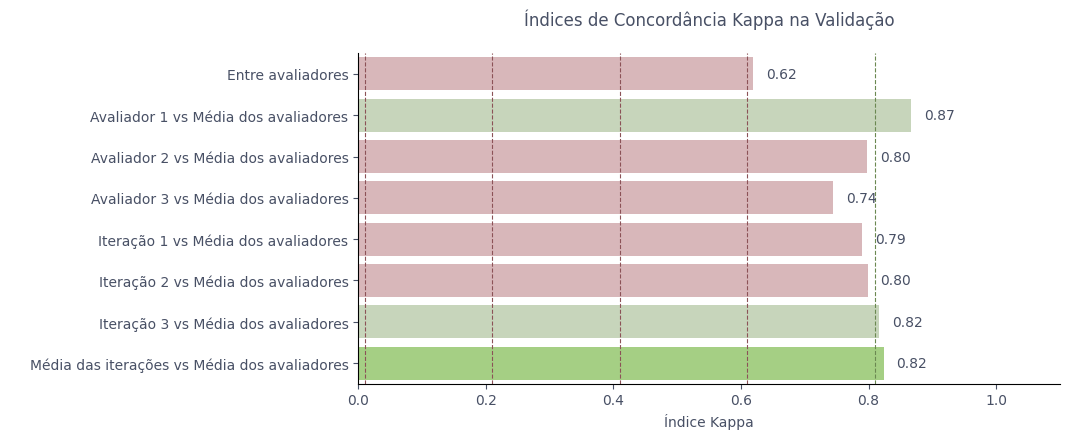

In [ ]:
labels_validation = [
    "Entre avaliadores",
    'Avaliador 1 vs Média dos avaliadores',
    'Avaliador 2 vs Média dos avaliadores',
    'Avaliador 3 vs Média dos avaliadores',
    'Iteração 1 vs Média dos avaliadores',
    'Iteração 2 vs Média dos avaliadores',
    'Iteração 3 vs Média dos avaliadores',
    'Média das iterações vs Média dos avaliadores'
]
kappas_validation = [
    fleiss_k_human_evals,
    k_av1_avg_avs,
    k_av2_avg_avs,
    k_av3_avg_avs,
    k_it1_avg_avs,
    k_it2_avg_avs,
    k_it3_avg_avs,
    k_avg
]

plot_df_validation = pd.DataFrame({
    'Comparação': labels_validation,
    'Kappa': kappas_validation
})

hex_codes = {
    "green": "#C7D9B7",
    "green_2": "#6B8851",
    "green_3": "#A4DB77",
    "red": "#DDB2B5",
    "red_2": "#8C5257",
    "red_3": "#BB4C55",
    "gray": "#485065",
    "gray_2": "#BCC3D6",
    "blue": "#87CEEB",
    "orange": "#FFA07A"
}

colors_validation = []
for i, k in enumerate(kappas_validation):
    label = labels_validation[i]
    if label == 'Média das iterações vs Média dos avaliadores':
      if k < 0.8:
          colors_validation.append(hex_codes["red_3"])
      else:
          colors_validation.append(hex_codes["green_3"])
    elif k >= 0.81:
        colors_validation.append(hex_codes["green"])
    else:
        colors_validation.append(hex_codes["red"])

plt.rcParams['text.color'] = hex_codes["gray"]
plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
plt.rcParams['xtick.color'] = hex_codes["gray"]
plt.rcParams['ytick.color'] = hex_codes["gray"]

plt.figure(figsize=(12, 6))
ax = plt.gca()

sns.barplot(x='Kappa', y='Comparação', data=plot_df_validation, palette=colors_validation, hue='Comparação', legend=False, ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Índice Kappa', color=hex_codes["gray"])
plt.ylabel(' ', color=hex_codes["gray"])
plt.title('Índices de Concordância Kappa na Validação', color=hex_codes["gray"],pad=20)
plt.xlim(0, 1.1)

y_text_pos_offset = -0.9

kappa_level_definitions = [
    (0.01, "Concordância Leve"),
    (0.21, "Concordância Razoável"),
    (0.41, "Concordância Moderada"),
    (0.61, "Concordância Substancial"),
    (0.81, "Concordância Quase Perfeita")
]

for threshold, level_text in kappa_level_definitions:
    line_and_text_color = hex_codes["green_2"] if level_text == "Concordância Quase Perfeita" else hex_codes["red_2"]

    plt.axvline(x=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)

for i, value in enumerate(kappas_validation):
    plt.text(value + 0.02, i, f'{value:.2f}', ha='left', va='center', color=hex_codes["gray"])

plt.xticks(color=hex_codes["gray"])
plt.yticks(color=hex_codes["gray"])

plt.tight_layout(rect=[0.05, 0.2, 0.95, 0.95])
plt.show()

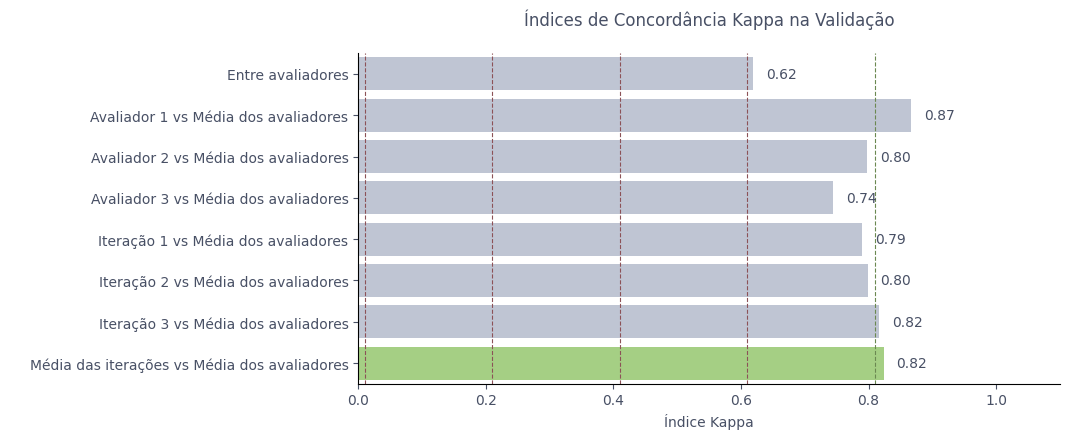

In [ ]:
colors_validation = []
highlight_label = 'Média das iterações vs Média dos avaliadores'
for i, k in enumerate(kappas_validation):
    label = labels_validation[i]
    if label == highlight_label:
        if k < 0.8:
            colors_validation.append(hex_codes["red_3"])
        else:
            colors_validation.append(hex_codes["green_3"])
    else:
        colors_validation.append(hex_codes["gray_2"])

plt.rcParams['text.color'] = hex_codes["gray"]
plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
plt.rcParams['xtick.color'] = hex_codes["gray"]
plt.rcParams['ytick.color'] = hex_codes["gray"]

plt.figure(figsize=(12, 6))
ax = plt.gca()

sns.barplot(x='Kappa', y='Comparação', data=plot_df_validation, palette=colors_validation, hue='Comparação', legend=False, ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Índice Kappa', color=hex_codes["gray"])
plt.ylabel(' ', color=hex_codes["gray"])
plt.title('Índices de Concordância Kappa na Validação', color=hex_codes["gray"],pad=20)
plt.xlim(0, 1.1)

y_text_pos_offset = -0.9

kappa_level_definitions = [
    (0.01, "Concordância Leve"),
    (0.21, "Concordância Razoável"),
    (0.41, "Concordância Moderada"),
    (0.61, "Concordância Substancial"),
    (0.81, "Concordância Quase Perfeita")
]

for threshold, level_text in kappa_level_definitions:
    line_and_text_color = hex_codes["green_2"] if level_text == "Concordância Quase Perfeita" else hex_codes["red_2"]

    plt.axvline(x=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)

for i, value in enumerate(kappas_validation):
    plt.text(value + 0.02, i, f'{value:.2f}', ha='left', va='center', color=hex_codes["gray"])

plt.xticks(color=hex_codes["gray"])
plt.yticks(color=hex_codes["gray"])

plt.tight_layout(rect=[0.05, 0.2, 0.95, 0.95])
plt.show()

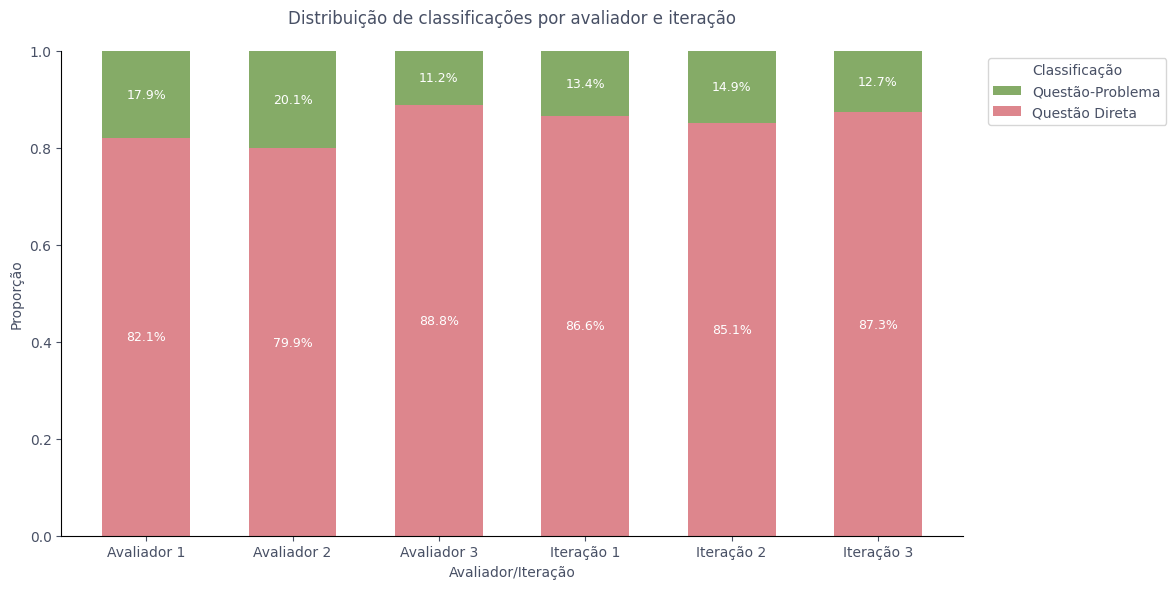

In [ ]:
classification_cols = [
    'av1_ehQuestaoProblema', 'av2_ehQuestaoProblema', 'av3_ehQuestaoProblema',
    'it1_ehQuestaoProblema', 'it2_ehQuestaoProblema', 'it3_ehQuestaoProblema'
]

label_mapping = {
    'av1_ehQuestaoProblema': 'Avaliador 1',
    'av2_ehQuestaoProblema': 'Avaliador 2',
    'av3_ehQuestaoProblema': 'Avaliador 3',
    'it1_ehQuestaoProblema': 'Iteração 1',
    'it2_ehQuestaoProblema': 'Iteração 2',
    'it3_ehQuestaoProblema': 'Iteração 3'
}

plot_data = []
for col in classification_cols:
    counts = final_comparison_df[col].value_counts(normalize=True).reindex([True, False], fill_value=0)
    plot_data.append({
        'Categoría': label_mapping[col],
        'Proporção True': counts.get(True, 0),
        'Proporção False': counts.get(False, 0)
    })

plot_df = pd.DataFrame(plot_data)

color_true = '#85AB67'
color_false = '#DD868D'

fig, ax = plt.subplots(figsize=(14, 6))

bar_false_container = ax.bar(plot_df['Categoría'], plot_df['Proporção False'], color=color_false, width=0.6)

bar_true_container = ax.bar(plot_df['Categoría'], plot_df['Proporção True'], bottom=plot_df['Proporção False'], color=color_true, width=0.6)

ax.set_xlabel('Avaliador/Iteração')
ax.set_ylabel('Proporção')
ax.set_title('Distribuição de classificações por avaliador e iteração', pad=20)
ax.set_ylim(0, 1)

handles = [bar_true_container, bar_false_container]
labels = ['Questão-Problema', 'Questão Direta']

ax.legend(handles=handles, labels=labels, title='Classificação', bbox_to_anchor=(1.02, 1), loc='upper left')

for bar_false, bar_true in zip(bar_false_container, bar_true_container):
    h_false = bar_false.get_height()
    h_true = bar_true.get_height()
    x = bar_false.get_x() + bar_false.get_width() / 2

    if h_false > 0:
        ax.text(x, h_false / 2, f'{h_false:.1%}', ha='center', va='center', color='white', fontsize=9)
    if h_true > 0:
        ax.text(x, h_false + h_true / 2, f'{h_true:.1%}', ha='center', va='center', color='white', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

##Análise de divergências

###Identificando as divergências

As divergências consideradas para análise foram aquelas onde a média das iterações divergiu do gabarito humano.

In [ ]:
comparacao_df = pd.read_csv('dataset_amostral_classificado.csv')

In [ ]:
divergencias_df = comparacao_df[comparacao_df['media_julgamentos_its'] != comparacao_df['media_julgamentos_avs']]

display(divergencias_df)

,id,enunciado,it1_ehQuestaoProblema,it2_ehQuestaoProblema,it3_ehQuestaoProblema,media_julgamentos_its,av1_ehQuestaoProblema,av2_ehQuestaoProblema,av3_ehQuestaoProblema,media_julgamentos_avs,prompt
0,2013-13,"Admita que um novo conectivo binário, rotulado...",False,False,False,False,True,True,True,True,\nQUESTÃO:\nAdmita que um novo conectivo binár...
42,2008-51,Considere o seguinte termo do cálculo-lambda:\...,True,True,False,True,False,False,False,False,\nQUESTÃO:\nConsidere o seguinte termo do cálc...
66,2002-27,Suponha que $T$ seja uma árvore AVL inicialmen...,True,True,True,True,False,False,False,False,\nQUESTÃO:\nSuponha que $T$ seja uma árvore AV...
85,2023-04,"Nos jogos da Mega-Sena, são sorteados a cada c...",False,False,False,False,True,True,False,True,"\nQUESTÃO:\nNos jogos da Mega-Sena, são sortea..."
94,2018-44,Considere um computador no qual o interpretado...,False,False,False,False,True,True,True,True,\nQUESTÃO:\nConsidere um computador no qual o ...
126,2011-50,Seja $G$ um grafo conexo com $n$ vértices. Con...,False,False,False,False,True,True,False,True,\nQUESTÃO:\nSeja $G$ um grafo conexo com $n$ v...


###Criação de prompts para a análise

In [ ]:
DIVERGING_PROMPT = """
O foco agora é entender as questões onde sua resposta, dentro do protocolo anterior, divergiu da classificação humana.
Você receberá a questão, o seu veredito anterior e o veredito dos humanos.
Responda com no máximo duas sentenças, justificando sua resposta e porque o seu veredito é válido.
Se for um caso limítrofe, onde você acredita que é possível enxergar ou não enxergar que a questão é problema/direta, deixe isso explícito.
Se você está certo de que o seu veredito foi o correto, justifique também.
"""

In [ ]:
REASONING_PROMPT = f"""
O prompt a seguir é o protocolo de anotação que você recebeu para classificar questões:

PROTOCOLO DE CLASSIFICAÇÃO:
'{SYSTEM_PROMPT}'

NOVO COMANDO:
{DIVERGING_PROMPT}
"""

In [ ]:
def gerar_prompt_justificativa(questao):
  PROMPT = f"""
QUESTÃO:
{questao['enunciado']}

SEU VEREDITO:
{questao['media_julgamentos_its']}

VEREDITO HUMANO:
{questao['media_julgamentos_avs']}
"""

  return PROMPT

In [ ]:
def recupera_justificativa(prompt):
  obj = get_completion(prompt, "gpt-5.4", REASONING_PROMPT)
  return (obj.choices[0].message.content)

###Solicitando justificativas do modelo

In [ ]:
divergencias_df['prompt'] = divergencias_df.apply(gerar_prompt_justificativa, axis=1)

/tmp/ipykernel_890/1364897405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divergencias_df['prompt'] = divergencias_df.apply(gerar_prompt_justificativa, axis=1)


In [ ]:
divergencias_df['justificativa_modelo'] = divergencias_df['prompt'].progress_apply(recupera_justificativa)

100%|██████████| 6/6 [00:13<00:00,  2.23s/it]
/tmp/ipykernel_890/1128878118.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divergencias_df['justificativa_modelo'] = divergencias_df['prompt'].progress_apply(recupera_justificativa)


In [ ]:
divergencias_df.head(1)

,id,enunciado,it1_ehQuestaoProblema,it2_ehQuestaoProblema,it3_ehQuestaoProblema,media_julgamentos_its,av1_ehQuestaoProblema,av2_ehQuestaoProblema,av3_ehQuestaoProblema,media_julgamentos_avs,prompt,justificativa_modelo
0,2013-13,"Admita que um novo conectivo binário, rotulado...",False,False,False,False,True,True,True,True,\nQUESTÃO:\nAdmita que um novo conectivo binár...,Embora a questão exija analisar uma tabela-ver...


In [ ]:
divergencias_df.to_csv('justificativas_divergencias_validacao.csv',index=False)

###Análise das justificativas

A análise contou com a criação de novas colunas booleanas: "caso_limitrofe", "houve_discordancia_humana" e "modelo_errou".

Nesta etapa, o pesquisador manualmente analisa as divergências e procura entender se o raciocínio do modelo poderia ser considerado como um acerto, mesmo que diferente da média dos humanos. Casos limítrofes frequentemente confundem o julgamento. Assim, a depender da justificativa, o julgamento pode ou não ser considerado um "erro", especialmente se também houve discordância entre avaliadores humanos.

Os casos limítrofes foram considerados aqueles que o modelo explicitamente aponta como limítrofes. A coluna "houve_discordancia_humana" também extrai a possibilidade de haver dúvidas na classificação. Assim, podemos analisar se o modelo costuma discordar em casos onde realmente houve discordância por parte dos humanos.

Abaixo, exibimos os resultados desta análise manual.



In [ ]:
justificativas_df = pd.read_csv('justificativas_divergencias_validacao_analisado.csv')

In [ ]:
justificativas_df.head(1)

,id,enunciado,it1_ehQuestaoProblema,it2_ehQuestaoProblema,it3_ehQuestaoProblema,media_julgamentos_its,av1_ehQuestaoProblema,av2_ehQuestaoProblema,av3_ehQuestaoProblema,media_julgamentos_avs,justificativa_modelo,caso_limitrofe,houve_discordancia_humana,modelo_errou
0,2013-13,"Admita que um novo conectivo binário, rotulado...",False,False,False,False,True,True,True,True,Embora a questão exija analisar uma tabela-ver...,True,False,True


In [ ]:
len(justificativas_df)

6

In [ ]:
borderline_divergences_df = justificativas_df[justificativas_df['caso_limitrofe'] == True]
count_borderline_divergences = len(borderline_divergences_df)
total_divergences = len(justificativas_df)

percentage_borderline_divergences = (count_borderline_divergences / total_divergences) * 100 if total_divergences > 0 else 0

print(f"Número de divergências que são casos limítrofes: {count_borderline_divergences}")
print(f"Porcentagem de divergências limítrofes (do total de divergências): {percentage_borderline_divergences:.2f}%")

Número de divergências que são casos limítrofes: 6
Porcentagem de divergências limítrofes (do total de divergências): 100.00%


In [ ]:
human_disagreement_divergences_df = justificativas_df[justificativas_df['houve_discordancia_humana'] == True]
count_human_disagreement_divergences = len(human_disagreement_divergences_df)
total_divergences = len(justificativas_df)

percentage_human_disagreement_divergences = (count_human_disagreement_divergences / total_divergences) * 100 if total_divergences > 0 else 0

print(f"Número de divergências onde houve discordância humana: {count_human_disagreement_divergences}")
print(f"Porcentagem de divergências com discordância humana (do total de divergências): {percentage_human_disagreement_divergences:.2f}%")

Número de divergências onde houve discordância humana: 2
Porcentagem de divergências com discordância humana (do total de divergências): 33.33%


In [ ]:
data = []
total_divergences = len(justificativas_df)

count_bl_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == True) & (justificativas_df['houve_discordancia_humana'] == True)])
percentage_bl_hd = (count_bl_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Limítrofes e com Discordância Humana',
    'Contagem': count_bl_hd,
    'Porcentagem': f'{percentage_bl_hd:.2f}%'
})

count_bl_no_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == True) & (justificativas_df['houve_discordancia_humana'] == False)])
percentage_bl_no_hd = (count_bl_no_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Limítrofes e sem Discordância Humana',
    'Contagem': count_bl_no_hd,
    'Porcentagem': f'{percentage_bl_no_hd:.2f}%'
})

count_no_bl_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == False) & (justificativas_df['houve_discordancia_humana'] == True)])
percentage_no_bl_hd = (count_no_bl_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Não Limítrofes e com Discordância Humana',
    'Contagem': count_no_bl_hd,
    'Porcentagem': f'{percentage_no_bl_hd:.2f}%'
})

count_no_bl_no_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == False) & (justificativas_df['houve_discordancia_humana'] == False)])
percentage_no_bl_no_hd = (count_no_bl_no_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Não Limítrofes e sem Discordância Humana',
    'Contagem': count_no_bl_no_hd,
    'Porcentagem': f'{percentage_no_bl_no_hd:.2f}%'
})

results_df = pd.DataFrame(data)
display(results_df)


,Categoria,Contagem,Porcentagem
0,Limítrofes e com Discordância Humana,2,33.33%
1,Limítrofes e sem Discordância Humana,4,66.67%
2,Não Limítrofes e com Discordância Humana,0,0.00%
3,Não Limítrofes e sem Discordância Humana,0,0.00%


Os casos podem ser interpretados da seguinte forma:

*   Divergências limítrofes (segundo o modelo) e onde houve discordância humana: A depender da justificativa do modelo, pode-se desconsiderar a divergência e admitir que a resposta do modelo foi plausível ("acerto").
*   Divergências limítrofes (segundo o modelo) e onde não houve discordância humana: Se todos os avaliadores concordaram entre si, mas o modelo ficou em dúvida, é necessário entender a justificativa do modelo, embora seja mais provável considerar de fato a divergência como erro.
*   Divergências não limítrofes (segundo o modelo) e onde houve discordância humana: Analisa-se a justificativa do modelo. Se a justificativa é válida, é possivel considerar que o modelo possivelmente acertou, e os humanos se confundiram.
*   Divergências não limítrofes (segundo o modelo) e onde não houve discordância humana: É o pior caso, onde o modelo tem confiança de uma resposta totalmente discordante com todos os avaliadores. Nesse caso, considera-se que o modelo está errado.



In [ ]:
total_divergences = len(justificativas_df)

errors_df = justificativas_df[justificativas_df['modelo_errou'] == True]
count_errors = len(errors_df)
percentage_errors = (count_errors / total_divergences) * 100 if total_divergences > 0 else 0

disregarded_df = justificativas_df[justificativas_df['modelo_errou'] == False]
count_disregarded = len(disregarded_df)
percentage_disregarded = (count_disregarded / total_divergences) * 100 if total_divergences > 0 else 0

print(f"\nNúmero de divergências onde o modelo errou: {count_errors} ({percentage_errors:.2f}%)")
print(f"Número de divergências onde o modelo não errou (desconsideradas): {count_disregarded} ({percentage_disregarded:.2f}%)")


Número de divergências onde o modelo errou: 4 (66.67%)
Número de divergências onde o modelo não errou (desconsideradas): 2 (33.33%)


In [ ]:
total_cases = 134
model_errors = count_errors

agreement_cases = total_cases - model_errors
percentage_agreement = (agreement_cases / total_cases) * 100

print(f"De um total de {total_cases} casos:")
print(f"  Casos em que o modelo acertou ou a divergência foi desconsiderada: {agreement_cases}")
print(f"  Nova porcentagem geral de concordância: {percentage_agreement:.2f}%")
print(f"  Nova porcentagem geral de discordância: {(100-percentage_agreement):.2f}%")

De um total de 134 casos:
  Casos em que o modelo acertou ou a divergência foi desconsiderada: 130
  Nova porcentagem geral de concordância: 97.01%
  Nova porcentagem geral de discordância: 2.99%


In [ ]:
from statsmodels.stats.proportion import proportion_confint

conf_interval_errors = proportion_confint(count=model_errors, nobs=total_cases, alpha=0.05, method='wilson')

lower_bound_percent = conf_interval_errors[0] * 100
upper_bound_percent = conf_interval_errors[1] * 100

print(f"Intervalo de Confiança de 95% para a porcentagem de erros: ({lower_bound_percent:.2f}%, {upper_bound_percent:.2f}%)")

Intervalo de Confiança de 95% para a porcentagem de erros: (1.17%, 7.42%)


In [ ]:
print("\nAnálise de Falsos Positivos e Falsos Negativos (Geral para erros do modelo)")

true_model_errors_df = justificativas_df[justificativas_df['modelo_errou'] == True]

if true_model_errors_df.empty:
    print("Não há erros definitivos do modelo para analisar falsos positivos e falsos negativos.")
else:
    total_errors_overall = len(true_model_errors_df)

    total_fp_overall = true_model_errors_df[
        (true_model_errors_df['media_julgamentos_its'] == True) &
        (true_model_errors_df['media_julgamentos_avs'] == False)
    ].shape[0]
    percentage_fp_overall = (total_fp_overall / total_errors_overall) * 100 if total_errors_overall > 0 else 0

    total_fn_overall = true_model_errors_df[
        (true_model_errors_df['media_julgamentos_its'] == False) &
        (true_model_errors_df['media_julgamentos_avs'] == True)
    ].shape[0]
    percentage_fn_overall = (total_fn_overall / total_errors_overall) * 100 if total_errors_overall > 0 else 0

    percentage_true_model_errors = total_errors_overall / len(justificativas_df) * 100

    print(f"  Total de discordâncias: {len(justificativas_df)}")
    print(f"  Total de erros definitivos do modelo: {total_errors_overall} ({percentage_true_model_errors:.2f}%)")
    print(f"  Falsos Positivos (entre os definitivos): {total_fp_overall} ({percentage_fp_overall:.2f}%)")
    print(f"  Falsos Negativos (entre os definitivos): {total_fn_overall} ({percentage_fn_overall:.2f}%)")


Análise de Falsos Positivos e Falsos Negativos (Geral para erros do modelo)
  Total de discordâncias: 6
  Total de erros definitivos do modelo: 4 (66.67%)
  Falsos Positivos (entre os definitivos): 1 (25.00%)
  Falsos Negativos (entre os definitivos): 3 (75.00%)


##Classificação de todo o dataset

### Organização do dataset e execução

In [ ]:
poscomp_ds = pd.read_json('dataset_completo.json')

In [ ]:
poscomp_ds['prompt'] = poscomp_ds.apply(gerar_prompt, axis = 1)

In [ ]:
poscomp_ds.head()

,id,edicao,numero,enunciado,alternativas,area_conhecimento,area,subarea,gabarito,atributo_rag,prompt
0,2002-01,2002,1,Pode-se afirmar que o gráfico da função $y = 2...,[a) transladado uma unidade para a direita e d...,Matemática,Geometria Analítica,Reta no plano e no espaço,A,matematica - geometria analitica - reta no pla...,\nQUESTÃO:\nPode-se afirmar que o gráfico da f...
1,2002-02,2002,2,A derivada da função $f(x) = x^x$ é igual a,"[a) $xx^{x-1}$, b) $x^x$, c) $x^x \ln(x)$, d) ...",Matemática,Cálculo Diferencial e Integral,Funções Reais de uma Variável: Continuidade e ...,D,matematica - calculo diferencial e integral - ...,\nQUESTÃO:\nA derivada da função $f(x) = x^x$ ...
2,2002-03,2002,3,Seja $n$ um número inteiro positivo. Considere...,"[a) 5, b) 4, c) 6, d) 3, e) 2]",Matemática,Matemática Discreta,"Iteração, Indução e Recursão",B,"matematica - matematica discreta - iteracao, i...",\nQUESTÃO:\nSeja $n$ um número inteiro positiv...
3,2002-04,2002,4,"Para cada $n \in \mathbb{N}$ seja $D_n = (0, 1...","[a) $D_3$, b) $D_{20}$, c) $(1/20, 1/3)$, d) $...",Matemática,Matemática Discreta,Conjuntos e Álgebra de Conjuntos como uma Teor...,D,matematica - matematica discreta - conjuntos e...,\nQUESTÃO:\nPara cada $n \in \mathbb{N}$ seja ...
4,2002-05,2002,5,Todos os convidados presentes num jantar tomam...,"[a) 19, b) 27, c) 23, d) 15, e) 10]",Matemática,Análise Combinatória,Princípio de Inclusão e Exclusão,A,matematica - analise combinatoria - principio ...,\nQUESTÃO:\nTodos os convidados presentes num ...


In [ ]:
#poscomp_ds = poscomp_ds.head(1)

###Rodando a classificação

In [ ]:
CHUNK_SIZE = 50
TARGET_ITERATION = 4

temp_filename = f'temp_classified_dataset_it{TARGET_ITERATION}.csv'
final_filename = 'dataset_completo_classificado.csv'

validation_df_path = 'dataset_modelo_validacao.csv'
validation_ids = []
validation_classifications_for_it4 = pd.DataFrame()

if os.path.exists(validation_df_path):
    validation_df_original = pd.read_csv(validation_df_path)
    validation_ids = validation_df_original['id'].tolist()
    print(f"Loaded {len(validation_ids)} question IDs from validation dataset. These will not be re-classified by the model for it{TARGET_ITERATION}.")

    for col in ['it1_ehQuestaoProblema', 'it2_ehQuestaoProblema', 'it3_ehQuestaoProblema']:
        if col in validation_df_original.columns:
            validation_df_original[col] = validation_df_original[col].astype(bool)
            validation_df_original[f'{col}_numeric'] = validation_df_original[col].astype(int)

    numeric_cols = [f'it{i}_ehQuestaoProblema_numeric' for i in range(1, 4) if f'it{i}_ehQuestaoProblema_numeric' in validation_df_original.columns]
    if numeric_cols:
        validation_df_original['media_julgamentos_its'] = (validation_df_original[numeric_cols].mean(axis=1) >= 0.5).astype(bool)
    else:
        print("WARNING: No iteration columns found in validation dataset to calculate 'media_julgamentos_its'.")
        validation_df_original['media_julgamentos_its'] = False

    validation_classifications_for_it4 = validation_df_original[['id', 'media_julgamentos_its']].rename(
        columns={'media_julgamentos_its': f'it{TARGET_ITERATION}_ehQuestaoProblema'}
    )
    print(f"Prepared {len(validation_classifications_for_it4)} validation questions with their 'it{TARGET_ITERATION}_ehQuestaoProblema' from 'media_julgamentos_its'.")
else:
    print("Validation dataset 'dataset_modelo_validacao.csv' not found. All questions in poscomp_ds will be processed.")

df_to_classify_by_model = poscomp_ds[~poscomp_ds['id'].isin(validation_ids)].copy()

newly_classified_results = []
already_processed_ids_in_temp = set()

if os.path.exists(temp_filename):
    print(f"Loading existing temporary data from {temp_filename} to resume processing of non-validation questions.")
    existing_temp_df = pd.read_csv(temp_filename)
    newly_classified_results.append(existing_temp_df)
    already_processed_ids_in_temp.update(existing_temp_df['id'].tolist())
    print(f"Resuming from {len(already_processed_ids_in_temp)} non-validation questions already processed.")

df_to_process_now = df_to_classify_by_model[~df_to_classify_by_model['id'].isin(already_processed_ids_in_temp)].copy()

total_questions_to_process_now = len(df_to_process_now)
num_chunks = (total_questions_to_process_now + CHUNK_SIZE - 1) // CHUNK_SIZE

print(f"Total NEW non-validation questions remaining to process by model: {total_questions_to_process_now}")
if total_questions_to_process_now > 0:
    print(f"Processing in chunks of {CHUNK_SIZE} questions for iteration {TARGET_ITERATION}.")

    try:
        for i in tqdm(range(num_chunks), desc=f"Classifying non-validation questions for it{TARGET_ITERATION}"):
            start_idx = i * CHUNK_SIZE
            end_idx = min((i + 1) * CHUNK_SIZE, total_questions_to_process_now)

            chunk_to_process = df_to_process_now.iloc[start_idx:end_idx].copy()
            processed_chunk = iteracao_prompt(chunk_to_process, TARGET_ITERATION)
            newly_classified_results.append(processed_chunk[['id', f'it{TARGET_ITERATION}_ehQuestaoProblema']])

            current_temp_df = pd.concat(newly_classified_results, ignore_index=True)
            current_temp_df.to_csv(temp_filename, index=False)
            print(f"Progress saved to {temp_filename} ({len(current_temp_df)} non-validation questions classified).")

    except Exception as e:
        print(f"An error occurred during processing: {e}")
        print(f"Saving partially classified data to {final_filename} due to error.")

        combined_new_classifications_df = pd.DataFrame(columns=['id', f'it{TARGET_ITERATION}_ehQuestaoProblema'])
        if newly_classified_results:
            combined_new_classifications_df = pd.concat(newly_classified_results, ignore_index=True)
        elif os.path.exists(temp_filename):
            combined_new_classifications_df = pd.read_csv(temp_filename)

        final_it4_classifications = pd.concat([combined_new_classifications_df, validation_classifications_for_it4], ignore_index=True)
        final_it4_classifications.drop_duplicates(subset='id', keep='first', inplace=True)
        final_it4_classifications.sort_values(by='id', inplace=True)

        final_dataset_in_memory = poscomp_ds.merge(
            final_it4_classifications,
            on='id',
            how='left'
        )
        final_dataset_in_memory.to_csv(final_filename, index=False)
        print(f"Saved {len(final_dataset_in_memory)} questions to {final_filename}. Note: it might be incomplete.")

    else:
        print("\nAll remaining non-validation questions processed successfully!")
        combined_new_classifications_df = pd.concat(newly_classified_results, ignore_index=True)

        final_it4_classifications = pd.concat([combined_new_classifications_df, validation_classifications_for_it4], ignore_index=True)
        final_it4_classifications.drop_duplicates(subset='id', keep='first', inplace=True)
        final_it4_classifications.sort_values(by='id', inplace=True)

        final_dataset_in_memory = poscomp_ds.merge(
            final_it4_classifications,
            on='id',
            how='left'
        )

        final_dataset_in_memory.to_csv(final_filename, index=False)
        print(f"Final classified dataset saved to {final_filename}.")

        if os.path.exists(temp_filename):
            os.remove(temp_filename)
            print(f"Temporary file {temp_filename} removed.")
else:
    print("No new non-validation questions to process by the model.")
    combined_new_classifications_df = pd.DataFrame(columns=['id', f'it{TARGET_ITERATION}_ehQuestaoProblema'])
    if newly_classified_results:
        combined_new_classifications_df = pd.concat(newly_classified_results, ignore_index=True)
    elif os.path.exists(temp_filename):
        combined_new_classifications_df = pd.read_csv(temp_filename)

    final_it4_classifications = pd.concat([combined_new_classifications_df, validation_classifications_for_it4], ignore_index=True)
    final_it4_classifications.drop_duplicates(subset='id', keep='first', inplace=True)
    final_it4_classifications.sort_values(by='id', inplace=True)

    final_dataset_in_memory = poscomp_ds.merge(
        final_it4_classifications,
        on='id',
        how='left'
    )
    final_dataset_in_memory.to_csv(final_filename, index=False)
    print(f"Final classified dataset (no new model runs) saved to {final_filename}.")

poscomp_ds = final_dataset_in_memory
print("\n'poscomp_ds' DataFrame in memory has been updated with the new classification column.")

Loaded 134 question IDs from validation dataset. These will not be re-classified by the model for it4.
Prepared 134 validation questions with their 'it4_ehQuestaoProblema' from 'media_julgamentos_its'.
Total NEW non-validation questions remaining to process by model: 1206
Processing in chunks of 50 questions for iteration 4.


Classifying non-validation questions for it4:   4%|▍         | 1/25 [00:30<12:20, 30.87s/it]

Progress saved to temp_classified_dataset_it4.csv (50 non-validation questions classified).



Classifying non-validation questions for it4:   8%|▊         | 2/25 [00:56<10:35, 27.63s/it]

Progress saved to temp_classified_dataset_it4.csv (100 non-validation questions classified).


...

Progress saved to temp_classified_dataset_it4.csv (1150 non-validation questions classified).



Classifying non-validation questions for it4:  96%|█████████▌| 24/25 [11:09<00:27, 27.22s/it]

Progress saved to temp_classified_dataset_it4.csv (1200 non-validation questions classified).



Classifying non-validation questions for it4: 100%|██████████| 25/25 [11:12<00:00, 26.90s/it]

Progress saved to temp_classified_dataset_it4.csv (1206 non-validation questions classified).

All remaining non-validation questions processed successfully!
Final classified dataset saved to dataset_completo_classificado.csv.
Temporary file temp_classified_dataset_it4.csv removed.

'poscomp_ds' DataFrame in memory has been updated with the new classification column.


In [ ]:
poscomp_ds.head(1)

,id,edicao,numero,enunciado,alternativas,area_conhecimento,area,subarea,gabarito,atributo_rag,prompt,it4_ehQuestaoProblema
0,2002-01,2002,1,Pode-se afirmar que o gráfico da função $y = 2...,[a) transladado uma unidade para a direita e d...,Matemática,Geometria Analítica,Reta no plano e no espaço,A,matematica - geometria analitica - reta no pla...,\nQUESTÃO:\nPode-se afirmar que o gráfico da f...,False


In [ ]:
poscomp_ds.rename(columns={'it4_ehQuestaoProblema': 'ehQuestaoProblema'}, inplace=True)
poscomp_ds.drop(columns=['prompt'], inplace=True)

In [ ]:
poscomp_ds.head(1)

,id,edicao,numero,enunciado,alternativas,area_conhecimento,area,subarea,gabarito,atributo_rag,ehQuestaoProblema
0,2002-01,2002,1,Pode-se afirmar que o gráfico da função $y = 2...,[a) transladado uma unidade para a direita e d...,Matemática,Geometria Analítica,Reta no plano e no espaço,A,matematica - geometria analitica - reta no pla...,False


In [ ]:
poscomp_ds.to_csv('dataset_completo_classificado.csv', index=False)

###Segunda versão: classificação híbrida

Uma vez com todas as classificações do modelo, também é possível utilizar as classificações humanas prioritariamente quando disponíveis (experimentos piloto e de validação), e usar as do modelo somente quando não existir gabarito humano.

In [ ]:
dataset_completo = pd.read_csv('dataset_completo_classificado.csv')
dataset_piloto = pd.read_csv('dataset_avs_piloto.csv')
dataset_amostral = pd.read_csv('dataset_avs_validacao.csv')

In [ ]:
for df in [dataset_piloto, dataset_amostral]:
    df['av1_ehQuestaoProblema_numeric'] = df['av1_ehQuestaoProblema'].astype(int)
    df['av2_ehQuestaoProblema_numeric'] = df['av2_ehQuestaoProblema'].astype(int)
    df['av3_ehQuestaoProblema_numeric'] = df['av3_ehQuestaoProblema'].astype(int)

    df['ehQuestaoProblema'] = (df[['av1_ehQuestaoProblema_numeric', 'av2_ehQuestaoProblema_numeric', 'av3_ehQuestaoProblema_numeric']].mean(axis=1) >= 0.5).astype(bool)
    df.drop(columns=['av1_ehQuestaoProblema_numeric', 'av2_ehQuestaoProblema_numeric', 'av3_ehQuestaoProblema_numeric'], inplace=True)

In [ ]:
dataset_hibrido = dataset_completo.copy()

piloto_map = dataset_piloto.set_index('id')['ehQuestaoProblema']
amostral_map = dataset_amostral.set_index('id')['ehQuestaoProblema']

dataset_hibrido['ehQuestaoProblema_temp'] = dataset_hibrido['id'].map(piloto_map)

dataset_hibrido['ehQuestaoProblema_temp'] = dataset_hibrido['ehQuestaoProblema_temp'].fillna(dataset_hibrido['id'].map(amostral_map))

dataset_hibrido['ehQuestaoProblema_temp'] = dataset_hibrido['ehQuestaoProblema_temp'].fillna(dataset_hibrido['ehQuestaoProblema'])

dataset_hibrido['ehQuestaoProblema'] = dataset_hibrido['ehQuestaoProblema_temp']

dataset_hibrido.drop(columns=['ehQuestaoProblema_temp'], inplace=True)

/tmp/ipykernel_9185/1458006162.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset_hibrido['ehQuestaoProblema_temp'] = dataset_hibrido['ehQuestaoProblema_temp'].fillna(dataset_hibrido['ehQuestaoProblema'])


In [ ]:
len(dataset_hibrido)

1340

In [ ]:
questoes_problema_hibrido = dataset_hibrido[dataset_hibrido['ehQuestaoProblema'] == True]
len(questoes_problema_hibrido)

209

In [ ]:
dataset_hibrido.to_csv('dataset_completo_classificado_hibrido.csv', index=False)

####Salvando as questões-problema

In [ ]:
questoes_problema_hibrido.to_csv('dataset_qps_hibrido.csv', index=False)

In [ ]:
questoes_problema = dataset_completo[dataset_completo['ehQuestaoProblema'] == True]
questoes_problema.to_csv('dataset_qps.csv', index=False)

##Análises

In [ ]:
df_amostral = pd.read_csv('dataset_amostral_classificado.csv')
df_completo = pd.read_csv('dataset_completo_classificado_hibrido.csv')

In [ ]:
print('Proporção de Questões-Problema e Questões Diretas na amostra de validação:')
proportions_amostral = df_amostral['media_julgamentos_avs'].value_counts(normalize=True)
display(proportions_amostral.rename(index={True: 'Questão-Problema', False: 'Questão Direta'}))

print('\nProporção de Questões-Problema e Questões Diretas no dataset completo:')
proportions_completo = df_completo['ehQuestaoProblema'].value_counts(normalize=True)
display(proportions_completo.rename(index={True: 'Questão-Problema', False: 'Questão Direta'}))

Proporção de Questões-Problema e Questões Diretas na amostra de validação:


,proportion
media_julgamentos_avs,
Questão Direta,0.843284
Questão-Problema,0.156716



Proporção de Questões-Problema e Questões Diretas no dataset completo:


,proportion
ehQuestaoProblema,
Questão Direta,0.84403
Questão-Problema,0.15597


In [ ]:
data = {
    'Tipo de Questão': ['Questão Direta', 'Questão-Problema'],
    'Experimento de Validação': [0.843284, 0.156716],
    'Dataset Completo': [0.84403, 0.15597]
}

df_percentages = pd.DataFrame(data)
df_percentages['Experimento de Validação'] = df_percentages['Experimento de Validação'].apply(lambda x: f'{x:.2%}')
df_percentages['Dataset Completo'] = df_percentages['Dataset Completo'].apply(lambda x: f'{x:.2%}')

display(df_percentages)

,Tipo de Questão,Experimento de Validação,Dataset Completo
0,Questão Direta,84.33%,84.40%
1,Questão-Problema,15.67%,15.60%


In [ ]:
import statsmodels.stats.proportion as smp

proportion_problem_completo = df_completo['ehQuestaoProblema'].value_counts(normalize=True).get(True, 0)

num_problem_questions = df_amostral['media_julgamentos_avs'].sum()

num_total_observations = len(df_amostral)

proportion_problem = num_problem_questions / num_total_observations

confidence_interval_lower, confidence_interval_upper = smp.proportion_confint(
    count=num_problem_questions,
    nobs=num_total_observations,
    alpha=0.05,
    method='wilson'
)

print(f"Proporção de Questões-Problema no dataset amostral: {proportion_problem:.4f}")
print(f"Intervalo de Confiança (95%) para a proporção: [{confidence_interval_lower:.4f}, {confidence_interval_upper:.4f}]")

is_in_interval = (
    confidence_interval_lower <= proportion_problem_completo <=
    confidence_interval_upper
)

print(f"\nProporção de Questões-Problema no dataset completo: {proportion_problem_completo:.4f}")
if is_in_interval:
    print("A proporção de questões-problema do dataset completo ESTÁ no intervalo de confiança do dataset amostral.")
else:
    print("A proporção de questões-problema do dataset completo NÃO ESTÁ no intervalo de confiança do dataset amostral.")

Proporção de Questões-Problema no dataset amostral: 0.1567
Intervalo de Confiança (95%) para a proporção: [0.1048, 0.2277]

Proporção de Questões-Problema no dataset completo: 0.1560
A proporção de questões-problema do dataset completo ESTÁ no intervalo de confiança do dataset amostral.


# Demonstração do classificador

Esta seção visa executar o classificador em uma demo rápida, onde os espectadores podem sugerir enunciados ou classificar uma questão aleatória do dataset do POSCOMP.

Sugere-se que os espectadores tentem classificar manualmente antes de rodar a classificação automática, para que seja possível atestar se há concordância ou não entre humano e LLM em cenários reais.

## Instruções para carregar e preparar os dados

1.   Carregue o arquivo "dataset_completo.json" e o renomeie para "dataset.json"
2.   Rode da seção "Instalação de dependências" até a seção "Geração de prompts".
3.   Rode o restante desta seção, então passe para a seção "Código para a demo" abaixo.

Nesta seção, verificamos se o dataset foi carregado corretamente. Então, geramos o prompt para todos os enunciados, a fim de que a demo seja bem-sucedida.

É possível carregar outros datasets além do poscomp, desde que sua estrutura seja compatível com as colunas que são trabalhadas no classificador.

In [ ]:
poscomp_ds.head(1)

,id,enunciado,texto_parcial
0,2002-01,Pode-se afirmar que o gráfico da função $y = 2...,Pode-se afirmar que o gráfico da função $y = 2...


In [ ]:
poscomp_ds['prompt'] = poscomp_ds.apply(gerar_prompt, axis = 1)

In [ ]:
poscomp_ds.head(1)

,id,enunciado,texto_parcial,prompt
0,2002-01,Pode-se afirmar que o gráfico da função $y = 2...,Pode-se afirmar que o gráfico da função $y = 2...,\nQUESTÃO:\nPode-se afirmar que o gráfico da f...


Em seguida, adaptamos a função "recupera_resposta" para que sua saída seja mais legível.

In [ ]:
def recupera_resposta_demo(enunciado_questao):
  obj = get_completion(enunciado_questao, "gpt-5.4", SYSTEM_PROMPT)
  resposta_modelo = obj.choices[0].message.content.strip().lower()
  if resposta_modelo == 'true':
    return "A questão é problema"
  elif resposta_modelo == 'false':
    return "A questão é direta"
  else:
    return "Não foi possível classificar a questão."

## Código para a demo

Para fins de uma demonstração rápida do classificador, é possível escolher uma questão aleatória do dataset do poscomp, ou inserir um enunciado novo.

In [ ]:
import random

In [ ]:
n_questao = random.randint(0, 1339) #um número entre 0 e 1339, correspondendo a todas as questões do dataset do POSCOMP
questao = poscomp_ds.iloc[n_questao]

Comente a linha ```enunciado_questao = questao["prompt"]```
para que o enunciado personalizado seja utilizado!

In [ ]:
enunciado_questao = """
QUESTÃO:

Insira sua questão aqui.
"""

enunciado_questao = questao["prompt"]

In [ ]:
print(enunciado_questao)


QUESTÃO:
Considere o programa:
```
program p;
   var n: integer;
   function f(n: integer; var k: integer): integer;
      var p,q:integer;
   begin (* f *)
      if n < 2
         then begin
               f :=n;
               k := 0
            end
         else begin
               f := f(n-1, p) + f(n-2, q);
               k := p + q + 1 
            end;
      write(n,' ',k,'; ')
   end (* f *); 
   begin
   n := 4; 
   write (f (3,n) ,n)
   end.
```
A complexidade desse Algoritmo é:



Antes de executar a célula abaixo, convide seu público a pensar sobre a natureza da questão. É uma questão direta ou uma questão-problema?

Depois, confira se o julgamento do classificador concorda com o julgamento humano.

In [ ]:
print(recupera_resposta_demo(enunciado_questao))

A questão é problema
